The goal of this notebook is to test every version of the algoritms we developed. 
- With and without edge reduction
- For rank_width and rank_width_sa test every of the initial conditions in Phase A and B

We have two datasets
- Dataset 1 p sweep fixed nodes
- Dataset 2 n sweep fixed p

In [ ]:
import os
import pickle
import networkx as nx
import numpy as np
from pathlib import Path

# ──────────────────────────────────────────────
# Global constants
# ──────────────────────────────────────────────
MASTER_SEED = 25                       # reproducibility seed
DATASET_DIR = Path("step_2_dataset_small")      # output folder
GRAPHS_PER_SETTING = 20                  # graphs per (n, p) pair

## Save / Load utility functions

These two functions handle persistence.  Each dataset is stored as a single
`.pkl` file that maps `(n, p)` → list of 20 `nx.Graph` objects.

In [10]:
def save_dataset(dataset: dict, filename: str, dataset_dir: str = "step2_dataset") -> str:
    """
    Save a graph dataset to disk as a pickle file.

    Parameters
    ----------
    dataset : dict
        Mapping  (n, p) -> list[nx.Graph]  (the graphs for that setting).
    filename : str
        Name of the output file (e.g. "dataset_fixed_n30.pkl").
    dataset_dir : str
        Folder where the file is written.  Created if it does not exist.

    Returns
    -------
    str
        Absolute path of the saved file.
    """
    os.makedirs(dataset_dir, exist_ok=True)
    filepath = os.path.join(dataset_dir, filename)
    with open(filepath, "wb") as f:
        pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved {len(dataset)} settings → {filepath}  "
          f"({os.path.getsize(filepath) / 1024:.1f} KB)")
    return os.path.abspath(filepath)


def load_dataset(filename: str, dataset_dir: str = "step_2_dataset_small") -> dict:
    """
    Load a graph dataset from disk.

    Parameters
    ----------
    filename : str
        Name of the pickle file to load.
    dataset_dir : str
        Folder that contains the file.

    Returns
    -------
    dict
        Mapping  (n, p) -> list[nx.Graph].
    """
    filepath = os.path.join(dataset_dir, filename)
    with open(filepath, "rb") as f:
        dataset = pickle.load(f)
    total_graphs = sum(len(v) for v in dataset.values())
    print(f"Loaded {len(dataset)} settings ({total_graphs} graphs total) "
          f"from {filepath}")
    return dataset

## Core generator – connected and distinct Erdos–Renyi graphs

`generate_connected_distinct_graphs` draws random graphs one at a time,
keeping only those that are connected **and** not isomorphic to any graph
already accepted for this bucket.

In [ ]:
def generate_connected_distinct_graphs(
    n: int,
    p: float,
    count: int = 20,
    master_seed: int = MASTER_SEED,
    max_attempts: int = 100_000,
) -> list:
    """
    Generate `count` connected, pairwise non-isomorphic Erdos–Renyi G(n, p) graphs.

    Parameters
    ----------
    n : int
        Number of vertices.
    p : float
        Edge probability.
    count : int
        How many distinct connected graphs to collect.
    master_seed : int
        Base seed; the actual seed for the k-th attempt is
        ``master_seed * 10_000 + k`` so that different (n, p) pairs
        are reproducible independently.
    max_attempts : int
        Safety cap on the number of trials.

    Returns
    -------
    list[nx.Graph]
        A list of `count` graphs.

    Raises
    ------
    RuntimeError
        If `count` distinct connected graphs cannot be found within
        `max_attempts`.
    """
    # Derive a per-(n,p) seed so each bucket is independent
    rng = np.random.RandomState(
        abs(hash((master_seed, n, round(p, 4)))) % (2**31)
    )

    collected: list[nx.Graph] = []
    attempt = 0

    while len(collected) < count and attempt < max_attempts:
        seed_i = int(rng.randint(0, 2**31))
        G = nx.erdos_renyi_graph(n, p, seed=seed_i)
        attempt += 1

        # Must be connected
        if not nx.is_connected(G):
            continue

        # Must be non-isomorphic to every graph already collected
        is_duplicate = False
        for G_prev in collected:
            if nx.is_isomorphic(G, G_prev):
                is_duplicate = True
                break
        if is_duplicate:
            continue

        # Store the generation seed as graph attribute for traceability
        G.graph["seed"] = seed_i
        G.graph["n"] = n
        G.graph["p"] = p
        G.graph["index"] = len(collected)
        collected.append(G)

    if len(collected) < count:
        raise RuntimeError(
            f"Only found {len(collected)}/{count} distinct connected "
            f"G({n}, {p}) graphs in {max_attempts} attempts."
        )

    return collected

print("generate_connected_distinct_graphs  ready")

generate_connected_distinct_graphs  ready


## Dataset 1 – Fixed *n* = 20, varying *p*

Probability list: `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6 , 0.7, 0.8, 0.9]`

In [12]:
N_FIXED = 20
prob_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6 , 0.7, 0.8, 0.9]

dataset_1 = {}   # (n, p) -> list[nx.Graph]

for p in prob_list:
    print(f"  n={N_FIXED}, p={p} ... ", end="", flush=True)
    graphs = generate_connected_distinct_graphs(
        n=N_FIXED, p=p, count=GRAPHS_PER_SETTING, master_seed=MASTER_SEED
    )
    dataset_1[(N_FIXED, p)] = graphs
    avg_edges = np.mean([G.number_of_edges() for G in graphs])
    print(f"done  ({len(graphs)} graphs, avg edges = {avg_edges:.1f})")

print(f"\nDataset 1 complete: {len(dataset_1)} settings, "
      f"{sum(len(v) for v in dataset_1.values())} graphs total.")

  n=20, p=0.1 ... done  (30 graphs, avg edges = 24.8)
  n=20, p=0.2 ... done  (30 graphs, avg edges = 39.2)
  n=20, p=0.3 ... done  (30 graphs, avg edges = 24.8)
  n=20, p=0.2 ... done  (30 graphs, avg edges = 39.2)
  n=20, p=0.3 ... done  (30 graphs, avg edges = 56.3)
  n=20, p=0.4 ... done  (30 graphs, avg edges = 77.0)
  n=20, p=0.5 ... done  (30 graphs, avg edges = 56.3)
  n=20, p=0.4 ... done  (30 graphs, avg edges = 77.0)
  n=20, p=0.5 ... done  (30 graphs, avg edges = 94.9)
  n=20, p=0.6 ... done  (30 graphs, avg edges = 115.9)
  n=20, p=0.7 ... done  (30 graphs, avg edges = 94.9)
  n=20, p=0.6 ... done  (30 graphs, avg edges = 115.9)
  n=20, p=0.7 ... done  (30 graphs, avg edges = 132.1)
  n=20, p=0.8 ... done  (30 graphs, avg edges = 132.1)
  n=20, p=0.8 ... done  (30 graphs, avg edges = 151.3)
  n=20, p=0.9 ... done  (30 graphs, avg edges = 170.6)

Dataset 1 complete: 9 settings, 270 graphs total.
done  (30 graphs, avg edges = 151.3)
  n=20, p=0.9 ... done  (30 graphs, avg ed

## Dataset 2 – Fixed *p* = 0.65, varying *n*

Vertex count: *n* ∈ {6, 7, …, 30}

In [13]:
P_FIXED = 0.65
node_range = list(range(6, 31))   # 6, 7, ..., 30

dataset_2 = {}   # (n, p) -> list[nx.Graph]

for n in node_range:
    print(f"  n={n:>2d}, p={P_FIXED} ... ", end="", flush=True)
    graphs = generate_connected_distinct_graphs(
        n=n, p=P_FIXED, count=GRAPHS_PER_SETTING, master_seed=MASTER_SEED
    )
    dataset_2[(n, P_FIXED)] = graphs
    avg_edges = np.mean([G.number_of_edges() for G in graphs])
    print(f"done  ({len(graphs)} graphs, avg edges = {avg_edges:.1f})")

print(f"\n Dataset 2 complete: {len(dataset_2)} settings, "
      f"{sum(len(v) for v in dataset_2.values())} graphs total.")

  n= 6, p=0.65 ... done  (30 graphs, avg edges = 9.2)
  n= 7, p=0.65 ... done  (30 graphs, avg edges = 9.2)
  n= 7, p=0.65 ... done  (30 graphs, avg edges = 13.8)
  n= 8, p=0.65 ... done  (30 graphs, avg edges = 17.9)
  n= 9, p=0.65 ... done  (30 graphs, avg edges = 22.4)
  n=10, p=0.65 ... done  (30 graphs, avg edges = 13.8)
  n= 8, p=0.65 ... done  (30 graphs, avg edges = 17.9)
  n= 9, p=0.65 ... done  (30 graphs, avg edges = 22.4)
  n=10, p=0.65 ... done  (30 graphs, avg edges = 27.8)
  n=11, p=0.65 ... done  (30 graphs, avg edges = 35.2)
  n=12, p=0.65 ... done  (30 graphs, avg edges = 27.8)
  n=11, p=0.65 ... done  (30 graphs, avg edges = 35.2)
  n=12, p=0.65 ... done  (30 graphs, avg edges = 42.3)
  n=13, p=0.65 ... done  (30 graphs, avg edges = 49.4)
  n=14, p=0.65 ... done  (30 graphs, avg edges = 42.3)
  n=13, p=0.65 ... done  (30 graphs, avg edges = 49.4)
  n=14, p=0.65 ... done  (30 graphs, avg edges = 58.5)
  n=15, p=0.65 ... done  (30 graphs, avg edges = 67.8)
  n=16, p=0.

## Save datasets to `step2_dataset_small/`

In [14]:
DATASET1_FILE = "dataset_fixed_n20_vary_p.pkl"
DATASET2_FILE = "dataset_fixed_p065_vary_n.pkl"

save_dataset(dataset_1, DATASET1_FILE,dataset_dir='step_2_dataset_small')
save_dataset(dataset_2, DATASET2_FILE, dataset_dir='step_2_dataset_small')

Saved 9 settings → step_2_dataset_small/dataset_fixed_n20_vary_p.pkl  (366.7 KB)
Saved 25 settings → step_2_dataset_small/dataset_fixed_p065_vary_n.pkl  (1166.5 KB)


'/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/step_2_dataset_small/dataset_fixed_p065_vary_n.pkl'

## Verification – reload and sanity-check

Reload the datasets from disk and confirm that every graph is connected,
and that within each bucket all 30 graphs are pairwise non-isomorphic.

In [15]:
def verify_dataset(dataset: dict) -> bool:
    """
    Verify that every graph in the dataset is connected and that graphs
    within each (n, p) bucket are pairwise non-isomorphic.

    Returns True if all checks pass.
    """
    all_ok = True
    for (n, p), graphs in sorted(dataset.items()):
        # Check count
        if len(graphs) != GRAPHS_PER_SETTING:
            print(f"  /!\  (n={n}, p={p}): expected {GRAPHS_PER_SETTING} graphs, got {len(graphs)}")
            all_ok = False
            continue

        # Check connectivity
        disconnected = [i for i, G in enumerate(graphs) if not nx.is_connected(G)]
        if disconnected:
            print(f"  /!\  (n={n}, p={p}): graphs {disconnected} are not connected")
            all_ok = False
            continue

        # Check pairwise non-isomorphism
        dup_found = False
        for i in range(len(graphs)):
            for j in range(i + 1, len(graphs)):
                if nx.is_isomorphic(graphs[i], graphs[j]):
                    print(f"  /!\  (n={n}, p={p}): graphs {i} and {j} are isomorphic")
                    dup_found = True
                    break
            if dup_found:
                break
        if dup_found:
            all_ok = False
            continue

        print(f"  YES  (n={n}, p={p}):  {len(graphs)} connected, distinct graphs")

    return all_ok


# Reload and verify Dataset 1
print("=" * 60)
print("DATASET 1    Fixed n=20, varying p")
print("=" * 60)
ds1 = load_dataset(DATASET1_FILE)
ok1 = verify_dataset(ds1)

print("\n" + "=" * 60)
print("DATASET 2    Fixed p=0.65, varying n")
print("=" * 60)
ds2 = load_dataset(DATASET2_FILE)
ok2 = verify_dataset(ds2)

print("\n" + "=" * 60)
if ok1 and ok2:
    print("YES  ALL CHECKS PASSED  both datasets are valid.")
else:
    print("/!\   Some checks FAILED review output above.")

DATASET 1    Fixed n=20, varying p
Loaded 9 settings (270 graphs total) from step_2_dataset_small/dataset_fixed_n20_vary_p.pkl
  YES  (n=20, p=0.1):  30 connected, distinct graphs
  YES  (n=20, p=0.2):  30 connected, distinct graphs
  YES  (n=20, p=0.3):  30 connected, distinct graphs
  YES  (n=20, p=0.4):  30 connected, distinct graphs
  YES  (n=20, p=0.5):  30 connected, distinct graphs
  YES  (n=20, p=0.6):  30 connected, distinct graphs
  YES  (n=20, p=0.7):  30 connected, distinct graphs
  YES  (n=20, p=0.8):  30 connected, distinct graphs
  YES  (n=20, p=0.9):  30 connected, distinct graphs

DATASET 2    Fixed p=0.65, varying n
Loaded 25 settings (750 graphs total) from step_2_dataset_small/dataset_fixed_p065_vary_n.pkl
  YES  (n=6, p=0.65):  30 connected, distinct graphs
  YES  (n=7, p=0.65):  30 connected, distinct graphs
  YES  (n=8, p=0.65):  30 connected, distinct graphs
  YES  (n=9, p=0.65):  30 connected, distinct graphs
  YES  (n=10, p=0.65):  30 connected, distinct graph

## Quick-reference: loading datasets from another notebook

Copy the snippet below into any other notebook to reload these datasets:

```python
import os, pickle

def load_dataset(filename, dataset_dir="step2_dataset"):
    with open(os.path.join(dataset_dir, filename), "rb") as f:
        return pickle.load(f)

# Dataset 1 – fixed n=20, varying p
ds1 = load_dataset("dataset_fixed_n30_vary_p.pkl")

# Dataset 2 – fixed p=0.65, varying n
ds2 = load_dataset("dataset_fixed_p065_vary_n.pkl")

# Example: get the 30 graphs for n=20, p=0.5
graphs_n30_p05 = ds1[(30, 0.5)]

# Example: get the 30 graphs for n=20, p=0.65
graphs_n20_p065 = ds2[(20, 0.65)]
```

## Simulations-load algos we have 

In [1]:
# Load the packages for the actual simualations
import optgraphstate as ogs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import stim
import igraph as ig
import scipy.io
from optgraphstate import GraphState
from networkx.utils import reverse_cuthill_mckee_ordering
# from lib.circuitSolver import *
# from lib.generate_graph import *
# from lib.tableau import *
from clustering import GreedyClustering, KernighanLinClustering
from clustering import Cluster

In [2]:
#Load the functions for linear rank width 
from rank_width import (linear_rank_width, lrw_of_ordering,
                        generate_initial_orderings, evaluate_ordering,
                        _relabel_to_int)

# Load the functions for linear rank width SA
from rank_width_sa import linear_rank_width_sa

# Load the functions for path_clustering
from path_clustering import path_clustering_lrw

# Load the function for SAminLA algo. Note that this serves function for the emission circuit
from optimization_script import run_optimization

In [ ]:
# --- Define Edge reduction function ---
def edge_reduction_func(input_graph):
    our_graph_original = input_graph.copy()
    # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
    mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

    # Create a new graph with integer labels
    our_graph = nx.relabel_nodes(our_graph_original, mapping)
    graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
    return graph



In [6]:
RESULTS_DIR = "/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small


In [ ]:
# Load the datasets
import os, pickle

def load_dataset(filename, dataset_dir="step_2_dataset_small"):
    with open(os.path.join(dataset_dir, filename), "rb") as f:
        return pickle.load(f)

# Dataset 1 – fixed n=20, varying p
ds1 = load_dataset("dataset_fixed_n20_vary_p.pkl")

# Dataset 2 – fixed p=0.65, varying n
ds2 = load_dataset("dataset_fixed_p065_vary_n.pkl")

## Emission circuit with no optimization and edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_random_label_edge_red = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)
        _, _, stats = run_optimization(
            G_sim, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_random_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_random_label_edge_red.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_random_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=7.2±0.9  cnots=16.0±5.7  gates=59.2±12.6
  n=20, p=0.2  (30 graphs) ... emitters=7.2±0.9  cnots=16.0±5.7  gates=59.2±12.6
  n=20, p=0.2  (30 graphs) ... emitters=8.3±0.8  cnots=38.1±9.9  gates=107.8±23.8
  n=20, p=0.3  (30 graphs) ... emitters=8.3±0.8  cnots=38.1±9.9  gates=107.8±23.8
  n=20, p=0.3  (30 graphs) ... emitters=9.0±0.6  cnots=58.3±10.1  gates=150.7±19.7
  n=20, p=0.4  (30 graphs) ... emitters=9.0±0.6  cnots=58.3±10.1  gates=150.7±19.7
  n=20, p=0.4  (30 graphs) ... emitters=9.2±0.5  cnots=72.0±6.3  gates=181.4±13.1
  n=20, p=0.5  (30 graphs) ... emitters=9.2±0.5  cnots=72.0±6.3  gates=181.4±13.1
  n=20, p=0.5  (30 graphs) ... emitters=9.1±0.4  cnots=71.7±7.4  gates=182.8±17.0
  n=20, p=0.6  (30 graphs) ... emitters=9.1±0.4  cnots=71.7±7.4  gates=182.8±17.0
  n=20, p=0.6  (30 graphs) ... emitters=9.2±0.6  cnots=70.9±7.6  gates=179.0±16.5
  n=20, p=0.7  (30 graphs) ... emitters=9.2±0.6  cnots=70.9±7.6  gates=179.0±16.5
  n=20, p=0.7  (

In [17]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_random_label_edge_red = {}

for (n, p), graphs in sorted(dataset_2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)
        _, _, stats = run_optimization(
            G_sim, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_random_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_random_label_edge_red.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_random_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=2.3±0.5  cnots=2.3±1.0  gates=13.6±3.6
  n= 7, p=0.65  (30 graphs) ... emitters=2.3±0.5  cnots=2.3±1.0  gates=13.6±3.6
  n= 7, p=0.65  (30 graphs) ... emitters=2.8±0.4  cnots=4.3±1.6  gates=19.5±5.2
  n= 8, p=0.65  (30 graphs) ... emitters=2.8±0.4  cnots=4.3±1.6  gates=19.5±5.2
  n= 8, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=6.0±2.2  gates=25.7±7.2
  n= 9, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=6.0±2.2  gates=25.7±7.2
  n= 9, p=0.65  (30 graphs) ... emitters=3.8±0.4  cnots=9.0±2.5  gates=32.8±7.3
  n=10, p=0.65  (30 graphs) ... emitters=3.8±0.4  cnots=9.0±2.5  gates=32.8±7.3
  n=10, p=0.65  (30 graphs) ... emitters=4.3±0.6  cnots=12.2±3.1  gates=43.2±7.5
  n=11, p=0.65  (30 graphs) ... emitters=4.3±0.6  cnots=12.2±3.1  gates=43.2±7.5
  n=11, p=0.65  (30 graphs) ... emitters=4.7±0.5  cnots=15.5±3.8  gates=53.8±10.2
  n=12, p=0.65  (30 graphs) ... emitters=4.7±0.5  cnots=15.5±3.8  gates=53.8±10.2
  n=12, p=0.65  (30 graphs) ... em

## Emission circuit with no optimization and NO edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_random_label_edge_red_no = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        
        _, _, stats = run_optimization(
            G, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_random_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_random_label_edge_red_no.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_random_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=7.2±0.9  cnots=16.4±5.5  gates=60.8±12.0
  n=20, p=0.2  (30 graphs) ... emitters=7.2±0.9  cnots=16.4±5.5  gates=60.8±12.0
  n=20, p=0.2  (30 graphs) ... emitters=8.3±0.8  cnots=37.8±9.9  gates=108.3±24.2
  n=20, p=0.3  (30 graphs) ... emitters=8.3±0.8  cnots=37.8±9.9  gates=108.3±24.2
  n=20, p=0.3  (30 graphs) ... emitters=9.0±0.6  cnots=58.9±9.7  gates=150.7±18.9
  n=20, p=0.4  (30 graphs) ... emitters=9.0±0.6  cnots=58.9±9.7  gates=150.7±18.9
  n=20, p=0.4  (30 graphs) ... emitters=9.2±0.5  cnots=71.6±5.8  gates=181.6±13.2
  n=20, p=0.5  (30 graphs) ... emitters=9.2±0.5  cnots=71.6±5.8  gates=181.6±13.2
  n=20, p=0.5  (30 graphs) ... emitters=9.1±0.4  cnots=76.1±6.3  gates=194.0±15.0
  n=20, p=0.6  (30 graphs) ... emitters=9.1±0.4  cnots=76.1±6.3  gates=194.0±15.0
  n=20, p=0.6  (30 graphs) ... emitters=9.2±0.6  cnots=75.1±7.8  gates=189.0±15.7
  n=20, p=0.7  (30 graphs) ... emitters=9.2±0.6  cnots=75.1±7.8  gates=189.0±15.7
  n=20, p=0.7  (30

In [19]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_random_label_edge_red_no = {}

for (n, p), graphs in sorted(dataset_2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        _, _, stats = run_optimization(
            G, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_random_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_random_label_edge_red_no.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_random_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=2.3±0.5  cnots=3.2±1.4  gates=19.9±4.0
  n= 7, p=0.65  (30 graphs) ... emitters=2.3±0.5  cnots=3.2±1.4  gates=19.9±4.0
  n= 7, p=0.65  (30 graphs) ... emitters=2.8±0.4  cnots=5.5±1.5  gates=28.6±3.9
  n= 8, p=0.65  (30 graphs) ... emitters=2.8±0.4  cnots=5.5±1.5  gates=28.6±3.9
  n= 8, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=7.7±2.0  gates=36.3±5.4
  n= 9, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=7.7±2.0  gates=36.3±5.4
  n= 9, p=0.65  (30 graphs) ... emitters=3.8±0.4  cnots=11.0±2.5  gates=43.9±7.1
  n=10, p=0.65  (30 graphs) ... emitters=3.8±0.4  cnots=11.0±2.5  gates=43.9±7.1
  n=10, p=0.65  (30 graphs) ... emitters=4.3±0.6  cnots=14.4±3.2  gates=53.1±6.5
  n=11, p=0.65  (30 graphs) ... emitters=4.3±0.6  cnots=14.4±3.2  gates=53.1±6.5
  n=11, p=0.65  (30 graphs) ... emitters=4.7±0.5  cnots=18.2±2.9  gates=62.0±7.2
  n=12, p=0.65  (30 graphs) ... emitters=4.7±0.5  cnots=18.2±2.9  gates=62.0±7.2
  n=12, p=0.65  (30 graphs) ... em

## Emission circuit with SAminLA and edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_saminla_label_edge_red = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        _, _, stats = run_optimization(
            G, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_saminla_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_saminla_label_edge_red.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_saminla_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... 

/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


emitters=2.9±0.7  cnots=8.0±3.9  gates=36.8±7.1
  n=20, p=0.2  (30 graphs) ... emitters=5.5±0.8  cnots=26.5±5.9  gates=74.9±16.7
  n=20, p=0.3  (30 graphs) ... emitters=5.5±0.8  cnots=26.5±5.9  gates=74.9±16.7
  n=20, p=0.3  (30 graphs) ... emitters=7.3±0.8  cnots=49.3±8.5  gates=125.7±21.4
  n=20, p=0.4  (30 graphs) ... emitters=7.3±0.8  cnots=49.3±8.5  gates=125.7±21.4
  n=20, p=0.4  (30 graphs) ... emitters=8.3±0.7  cnots=63.0±8.8  gates=158.6±21.2
  n=20, p=0.5  (30 graphs) ... emitters=8.3±0.7  cnots=63.0±8.8  gates=158.6±21.2
  n=20, p=0.5  (30 graphs) ... emitters=8.7±0.5  cnots=67.4±5.9  gates=169.0±15.4
  n=20, p=0.6  (30 graphs) ... emitters=8.7±0.5  cnots=67.4±5.9  gates=169.0±15.4
  n=20, p=0.6  (30 graphs) ... emitters=8.5±0.6  cnots=65.3±7.1  gates=163.7±18.1
  n=20, p=0.7  (30 graphs) ... emitters=8.5±0.6  cnots=65.3±7.1  gates=163.7±18.1
  n=20, p=0.7  (30 graphs) ... emitters=8.2±0.7  cnots=62.6±7.6  gates=159.4±19.3
  n=20, p=0.8  (30 graphs) ... emitters=8.2±0.7  cno

In [21]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_saminla_label_edge_red = {}

for (n, p), graphs in sorted(dataset_2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        
        _, _, stats = run_optimization(
            G, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_saminla_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_saminla_label_edge_red.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_saminla_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.6±1.4  gates=10.4±2.7
  n= 7, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.6±1.4  gates=10.4±2.7
  n= 7, p=0.65  (30 graphs) ... emitters=2.1±0.5  cnots=3.3±1.8  gates=15.5±5.1
  n= 8, p=0.65  (30 graphs) ... emitters=2.1±0.5  cnots=3.3±1.8  gates=15.5±5.1
  n= 8, p=0.65  (30 graphs) ... emitters=2.6±0.6  cnots=5.0±2.2  gates=19.8±5.7
  n= 9, p=0.65  (30 graphs) ... emitters=2.6±0.6  cnots=5.0±2.2  gates=19.8±5.7
  n= 9, p=0.65  (30 graphs) ... emitters=3.1±0.6  cnots=7.8±2.6  gates=27.5±6.9
  n=10, p=0.65  (30 graphs) ... emitters=3.1±0.6  cnots=7.8±2.6  gates=27.5±6.9
  n=10, p=0.65  (30 graphs) ... emitters=3.5±0.6  cnots=10.0±2.8  gates=34.9±9.3
  n=11, p=0.65  (30 graphs) ... emitters=3.5±0.6  cnots=10.0±2.8  gates=34.9±9.3
  n=11, p=0.65  (30 graphs) ... emitters=3.9±0.6  cnots=13.3±2.8  gates=43.9±8.3
  n=12, p=0.65  (30 graphs) ... emitters=3.9±0.6  cnots=13.3±2.8  gates=43.9±8.3
  n=12, p=0.65  (30 graphs) ... emit

## Emission circuit with SAminLA and NO edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_saminla_label_edge_red_no = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        _, _, stats = run_optimization(
            G, edge_reduction=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_saminla_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_saminla_label_edge_red_no.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_saminla_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=3.1±0.7  cnots=8.8±4.3  gates=39.8±8.0
  n=20, p=0.2  (30 graphs) ... emitters=3.1±0.7  cnots=8.8±4.3  gates=39.8±8.0
  n=20, p=0.2  (30 graphs) ... emitters=5.4±0.8  cnots=27.1±6.9  gates=75.0±15.9
  n=20, p=0.3  (30 graphs) ... emitters=5.4±0.8  cnots=27.1±6.9  gates=75.0±15.9
  n=20, p=0.3  (30 graphs) ... emitters=7.4±0.8  cnots=48.2±8.4  gates=125.3±20.9
  n=20, p=0.4  (30 graphs) ... emitters=7.4±0.8  cnots=48.2±8.4  gates=125.3±20.9
  n=20, p=0.4  (30 graphs) ... emitters=8.3±0.6  cnots=65.2±8.8  gates=166.4±18.9
  n=20, p=0.5  (30 graphs) ... emitters=8.3±0.6  cnots=65.2±8.8  gates=166.4±18.9
  n=20, p=0.5  (30 graphs) ... emitters=8.8±0.4  cnots=72.5±8.1  gates=186.9±20.1
  n=20, p=0.6  (30 graphs) ... emitters=8.8±0.4  cnots=72.5±8.1  gates=186.9±20.1
  n=20, p=0.6  (30 graphs) ... emitters=8.8±0.4  cnots=73.6±6.5  gates=187.6±12.2
  n=20, p=0.7  (30 graphs) ... emitters=8.8±0.4  cnots=73.6±6.5  gates=187.6±12.2
  n=20, p=0.7  (30 graph

In [23]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_saminla_label_edge_red_no = {}

for (n, p), graphs in sorted(dataset_2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        
        _, _, stats = run_optimization(
            G, edge_reduction=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_saminla_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_saminla_label_edge_red_no.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_saminla_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=2.1±0.4  cnots=2.9±1.4  gates=19.4±4.3
  n= 7, p=0.65  (30 graphs) ... emitters=2.1±0.4  cnots=2.9±1.4  gates=19.4±4.3
  n= 7, p=0.65  (30 graphs) ... emitters=2.6±0.5  cnots=5.3±2.2  gates=26.3±4.3
  n= 8, p=0.65  (30 graphs) ... emitters=2.6±0.5  cnots=5.3±2.2  gates=26.3±4.3
  n= 8, p=0.65  (30 graphs) ... emitters=3.0±0.4  cnots=7.3±2.1  gates=33.7±5.7
  n= 9, p=0.65  (30 graphs) ... emitters=3.0±0.4  cnots=7.3±2.1  gates=33.7±5.7
  n= 9, p=0.65  (30 graphs) ... emitters=3.4±0.6  cnots=10.2±2.5  gates=40.5±7.1
  n=10, p=0.65  (30 graphs) ... emitters=3.4±0.6  cnots=10.2±2.5  gates=40.5±7.1
  n=10, p=0.65  (30 graphs) ... emitters=4.0±0.4  cnots=13.7±2.5  gates=50.5±5.9
  n=11, p=0.65  (30 graphs) ... emitters=4.0±0.4  cnots=13.7±2.5  gates=50.5±5.9
  n=11, p=0.65  (30 graphs) ... emitters=4.5±0.6  cnots=17.6±3.5  gates=61.1±8.5
  n=12, p=0.65  (30 graphs) ... emitters=4.5±0.6  cnots=17.6±3.5  gates=61.1±8.5
  n=12, p=0.65  (30 graphs) ... em

## Emission circuit with path_clustering and edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_path_clustering_label_edge_red = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        cost, final_ordering = path_clustering_lrw(G_sim)

        ordered_graph = nx.relabel_nodes(G_sim, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)

        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_path_clustering_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_path_clustering_label_edge_red.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_path_clustering_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=3.1±0.7  cnots=8.2±3.6  gates=38.8±6.9
  n=20, p=0.2  (30 graphs) ... emitters=3.1±0.7  cnots=8.2±3.6  gates=38.8±6.9
  n=20, p=0.2  (30 graphs) ... emitters=5.1±0.6  cnots=26.5±7.3  gates=78.7±18.3
  n=20, p=0.3  (30 graphs) ... emitters=5.1±0.6  cnots=26.5±7.3  gates=78.7±18.3
  n=20, p=0.3  (30 graphs) ... emitters=6.4±0.6  cnots=46.3±8.5  gates=127.8±20.3
  n=20, p=0.4  (30 graphs) ... emitters=6.4±0.6  cnots=46.3±8.5  gates=127.8±20.3
  n=20, p=0.4  (30 graphs) ... emitters=6.8±0.4  cnots=55.6±8.4  gates=152.3±20.4
  n=20, p=0.5  (30 graphs) ... emitters=6.8±0.4  cnots=55.6±8.4  gates=152.3±20.4
  n=20, p=0.5  (30 graphs) ... emitters=7.1±0.4  cnots=58.9±5.7  gates=161.3±12.6
  n=20, p=0.6  (30 graphs) ... emitters=7.1±0.4  cnots=58.9±5.7  gates=161.3±12.6
  n=20, p=0.6  (30 graphs) ... emitters=6.9±0.3  cnots=57.3±5.9  gates=158.3±15.5
  n=20, p=0.7  (30 graphs) ... emitters=6.9±0.3  cnots=57.3±5.9  gates=158.3±15.5
  n=20, p=0.7  (30 graph

In [25]:
# ── Simulation – Dataset 2: ──────────

results_ds2_path_clustering_label_edge_red = {}

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        cost, final_ordering = path_clustering_lrw(G_sim)

        ordered_graph = nx.relabel_nodes(G_sim, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)

        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_path_clustering_label_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_path_clustering_label_edge_red.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_path_clustering_label_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n=6, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.3±1.1  gates=10.4±3.0
  n=7, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.3±1.1  gates=10.4±3.0
  n=7, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=2.9±1.6  gates=15.9±4.7
  n=8, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=2.9±1.6  gates=15.9±4.7
  n=8, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=4.5±1.8  gates=20.5±5.2
  n=9, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=4.5±1.8  gates=20.5±5.2
  n=9, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=7.1±2.5  gates=29.6±7.6
  n=10, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=7.1±2.5  gates=29.6±7.6
  n=10, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=8.8±2.4  gates=34.6±8.2
  n=11, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=8.8±2.4  gates=34.6±8.2
  n=11, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=10.9±2.5  gates=45.2±7.9
  n=12, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=10.9±2.5  gates=45.2±7.9
  n=12, p=0.65  (30 graphs) ... emitters=3.8±

## Emission circuit with path_clustering and NO edge reduction

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_path_clustering_label_edge_red_no = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        # G_sim = edge_reduction_func(G)

        cost, final_ordering = path_clustering_lrw(G)

        ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)

        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_path_clustering_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_path_clustering_label_edge_red_no.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_path_clustering_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=3.1±0.7  cnots=8.8±3.9  gates=41.2±9.0
  n=20, p=0.2  (30 graphs) ... emitters=3.1±0.7  cnots=8.8±3.9  gates=41.2±9.0
  n=20, p=0.2  (30 graphs) ... emitters=5.0±0.7  cnots=26.7±6.4  gates=81.8±18.7
  n=20, p=0.3  (30 graphs) ... emitters=5.0±0.7  cnots=26.7±6.4  gates=81.8±18.7
  n=20, p=0.3  (30 graphs) ... emitters=6.4±0.7  cnots=44.8±8.3  gates=127.1±21.1
  n=20, p=0.4  (30 graphs) ... emitters=6.4±0.7  cnots=44.8±8.3  gates=127.1±21.1
  n=20, p=0.4  (30 graphs) ... emitters=6.8±0.4  cnots=57.3±7.1  gates=156.6±17.2
  n=20, p=0.5  (30 graphs) ... emitters=6.8±0.4  cnots=57.3±7.1  gates=156.6±17.2
  n=20, p=0.5  (30 graphs) ... emitters=7.0±0.3  cnots=60.2±6.6  gates=168.4±15.0
  n=20, p=0.6  (30 graphs) ... emitters=7.0±0.3  cnots=60.2±6.6  gates=168.4±15.0
  n=20, p=0.6  (30 graphs) ... emitters=6.9±0.3  cnots=61.3±5.8  gates=169.6±13.1
  n=20, p=0.7  (30 graphs) ... emitters=6.9±0.3  cnots=61.3±5.8  gates=169.6±13.1
  n=20, p=0.7  (30 graph

In [27]:
# ── Simulation – Dataset 2: ──────────

results_ds2_path_clustering_label_edge_red_no = {}

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        # G_sim = edge_reduction_func(G)

        cost, final_ordering = path_clustering_lrw(G)

        ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)

        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_path_clustering_label_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_path_clustering_label_edge_red_no.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_path_clustering_label_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n=6, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=2.0±1.7  gates=18.2±4.5
  n=7, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=2.0±1.7  gates=18.2±4.5
  n=7, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=3.6±1.7  gates=24.7±3.9
  n=8, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=3.6±1.7  gates=24.7±3.9
  n=8, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=5.4±2.5  gates=31.5±5.9
  n=9, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=5.4±2.5  gates=31.5±5.9
  n=9, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=8.1±2.3  gates=37.4±6.3
  n=10, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=8.1±2.3  gates=37.4±6.3
  n=10, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=10.4±1.8  gates=45.3±7.1
  n=11, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=10.4±1.8  gates=45.3±7.1
  n=11, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=12.1±2.2  gates=52.8±7.6
  n=12, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=12.1±2.2  gates=52.8±7.6
  n=12, p=0.65  (30 graphs) ... emitters=3.

## Emission with rank_width and edge reduction (all 4 ordering variants)

For `refine=False` we extract the **3 individual Phase-A orderings** (Spectral, RCM, MinDegree) and evaluate each independently.  
With `refine=True` we get the **hill-climb refined** ordering on top.  
→ 4 result sets saved separately.

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────
# For each graph we get 4 orderings:
#   Spectral, RCM, MinDegree  (refine=False, Phase A/B only)
#   Refined                   (refine=True,  Phase A/B + C)
# and record circuit metrics for each.

ordering_names = ["spectral", "rcm", "mindegree", "refined"]

# One results dict per ordering variant
results_ds1_rw_spectral_edge_red  = {}
results_ds1_rw_rcm_edge_red       = {}
results_ds1_rw_mindegree_edge_red = {}
results_ds1_rw_refined_edge_red   = {}

all_result_dicts = [
    results_ds1_rw_spectral_edge_red,
    results_ds1_rw_rcm_edge_red,
    results_ds1_rw_mindegree_edge_red,
    results_ds1_rw_refined_edge_red,
]

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    # Per-variant raw lists: emitters, cnots, gates
    raw = {name: {"emitters": [], "cnots": [], "gates": []} for name in ordering_names}

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        # Relabel to 0..n-1 for the ordering functions
        G_int, old_to_new, new_to_old = _relabel_to_int(G_sim)

        # --- Phase A/B: three candidate orderings (no refinement) ---
        candidates = generate_initial_orderings(G_int)  # [spectral, rcm, mindegree]

        for name, ordering_int in zip(ordering_names[:3], candidates):
            # Map ordering back to original labels
            original_ordering = [new_to_old[v] for v in ordering_int]
            ordered_graph = nx.relabel_nodes(
                G_sim, {old: new for new, old in enumerate(original_ordering)}
            )
            _, _, stats = run_optimization(
                ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
            )
            raw[name]["emitters"].append(stats[0])
            raw[name]["cnots"].append(stats[1])
            raw[name]["gates"].append(stats[2])

        # --- Refined ordering (Phase A/B + C) ---
        _, refined_ordering = linear_rank_width(G_sim, refine=True)
        ordered_graph = nx.relabel_nodes(
            G_sim, {old: new for new, old in enumerate(refined_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        raw["refined"]["emitters"].append(stats[0])
        raw["refined"]["cnots"].append(stats[1])
        raw["refined"]["gates"].append(stats[2])

    # Aggregate and store
    for name, res_dict in zip(ordering_names, all_result_dicts):
        em = np.array(raw[name]["emitters"])
        cn = np.array(raw[name]["cnots"])
        gt = np.array(raw[name]["gates"])
        res_dict[(n, p)] = {
            "emitters_mean": em.mean(), "emitters_std": em.std(), "emitters_raw": em,
            "cnots_mean":    cn.mean(), "cnots_std":    cn.std(), "cnots_raw":    cn,
            "gates_mean":    gt.mean(), "gates_std":    gt.std(), "gates_raw":    gt,
        }

    # Print summary for each variant
    for name in ordering_names:
        d = all_result_dicts[ordering_names.index(name)][(n, p)]
        print(f"\n    {name:>10s}: emitters={d['emitters_mean']:.1f}±{d['emitters_std']:.1f}  "
              f"cnots={d['cnots_mean']:.1f}±{d['cnots_std']:.1f}  "
              f"gates={d['gates_mean']:.1f}±{d['gates_std']:.1f}", end="")
    print()

# Save all four result sets
for name, res_dict in zip(ordering_names, all_result_dicts):
    fpath = os.path.join(RESULTS_DIR, f"results_ds1_rw_{name}_edge_red.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... 
      spectral: emitters=3.1±0.8  cnots=8.0±3.9  gates=38.6±7.9
           rcm: emitters=4.2±1.2  cnots=9.6±4.2  gates=45.5±9.1
     mindegree: emitters=5.0±1.0  cnots=10.2±3.9  gates=44.6±6.8
       refined: emitters=2.9±0.7  cnots=7.9±4.2  gates=38.3±7.8
  n=20, p=0.2  (30 graphs) ... 
      spectral: emitters=3.1±0.8  cnots=8.0±3.9  gates=38.6±7.9
           rcm: emitters=4.2±1.2  cnots=9.6±4.2  gates=45.5±9.1
     mindegree: emitters=5.0±1.0  cnots=10.2±3.9  gates=44.6±6.8
       refined: emitters=2.9±0.7  cnots=7.9±4.2  gates=38.3±7.8
  n=20, p=0.2  (30 graphs) ... 
      spectral: emitters=5.6±1.0  cnots=27.6±7.4  gates=78.4±17.5
           rcm: emitters=6.2±0.9  cnots=30.0±9.5  gates=86.1±19.3
     mindegree: emitters=6.7±1.1  cnots=28.9±7.7  gates=79.7±18.1
       refined: emitters=5.2±0.8  cnots=27.2±7.3  gates=80.7±18.0
  n=20, p=0.3  (30 graphs) ... 
      spectral: emitters=5.6±1.0  cnots=27.6±7.4  gates=78.4±17.5
           rcm: emitters=6.2

In [29]:
# ── Simulation – Dataset 2: ──────────
# For each graph we get 4 orderings:
#   Spectral, RCM, MinDegree  (refine=False, Phase A/B only)
#   Refined                   (refine=True,  Phase A/B + C)
# and record circuit metrics for each.

ordering_names = ["spectral", "rcm", "mindegree", "refined"]

# One results dict per ordering variant
results_ds2_rw_spectral_edge_red  = {}
results_ds2_rw_rcm_edge_red       = {}
results_ds2_rw_mindegree_edge_red = {}
results_ds2_rw_refined_edge_red   = {}

all_result_dicts = [
    results_ds2_rw_spectral_edge_red,
    results_ds2_rw_rcm_edge_red,
    results_ds2_rw_mindegree_edge_red,
    results_ds2_rw_refined_edge_red,
]

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][1]):
    # Per-variant raw lists: emitters, cnots, gates
    raw = {name: {"emitters": [], "cnots": [], "gates": []} for name in ordering_names}

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        # Relabel to 0..n-1 for the ordering functions
        G_int, old_to_new, new_to_old = _relabel_to_int(G_sim)

        # --- Phase A/B: three candidate orderings (no refinement) ---
        candidates = generate_initial_orderings(G_int)  # [spectral, rcm, mindegree]

        for name, ordering_int in zip(ordering_names[:3], candidates):
            # Map ordering back to original labels
            original_ordering = [new_to_old[v] for v in ordering_int]
            ordered_graph = nx.relabel_nodes(
                G_sim, {old: new for new, old in enumerate(original_ordering)}
            )
            _, _, stats = run_optimization(
                ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
            )
            raw[name]["emitters"].append(stats[0])
            raw[name]["cnots"].append(stats[1])
            raw[name]["gates"].append(stats[2])

        # --- Refined ordering (Phase A/B + C) ---
        _, refined_ordering = linear_rank_width(G_sim, refine=True)
        ordered_graph = nx.relabel_nodes(
            G_sim, {old: new for new, old in enumerate(refined_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        raw["refined"]["emitters"].append(stats[0])
        raw["refined"]["cnots"].append(stats[1])
        raw["refined"]["gates"].append(stats[2])

    # Aggregate and store
    for name, res_dict in zip(ordering_names, all_result_dicts):
        em = np.array(raw[name]["emitters"])
        cn = np.array(raw[name]["cnots"])
        gt = np.array(raw[name]["gates"])
        res_dict[(n, p)] = {
            "emitters_mean": em.mean(), "emitters_std": em.std(), "emitters_raw": em,
            "cnots_mean":    cn.mean(), "cnots_std":    cn.std(), "cnots_raw":    cn,
            "gates_mean":    gt.mean(), "gates_std":    gt.std(), "gates_raw":    gt,
        }

    # Print summary for each variant
    for name in ordering_names:
        d = all_result_dicts[ordering_names.index(name)][(n, p)]
        print(f"\n    {name:>10s}: emitters={d['emitters_mean']:.1f}±{d['emitters_std']:.1f}  "
              f"cnots={d['cnots_mean']:.1f}±{d['cnots_std']:.1f}  "
              f"gates={d['gates_mean']:.1f}±{d['gates_std']:.1f}", end="")
    print()

# Save all four result sets
for name, res_dict in zip(ordering_names, all_result_dicts):
    fpath = os.path.join(RESULTS_DIR, f"results_ds2_rw_{name}_edge_red.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n=6, p=0.65  (30 graphs) ... 
      spectral: emitters=1.6±0.5  cnots=1.3±1.0  gates=10.4±2.9
           rcm: emitters=1.7±0.5  cnots=1.5±1.1  gates=10.6±2.8
     mindegree: emitters=1.8±0.6  cnots=1.5±1.1  gates=10.7±3.0
       refined: emitters=1.6±0.5  cnots=1.3±1.0  gates=10.4±2.9
  n=7, p=0.65  (30 graphs) ... 
      spectral: emitters=1.6±0.5  cnots=1.3±1.0  gates=10.4±2.9
           rcm: emitters=1.7±0.5  cnots=1.5±1.1  gates=10.6±2.8
     mindegree: emitters=1.8±0.6  cnots=1.5±1.1  gates=10.7±3.0
       refined: emitters=1.6±0.5  cnots=1.3±1.0  gates=10.4±2.9
  n=7, p=0.65  (30 graphs) ... 
      spectral: emitters=2.1±0.4  cnots=3.2±1.8  gates=16.5±5.3
           rcm: emitters=2.2±0.5  cnots=3.3±1.5  gates=16.3±4.1
     mindegree: emitters=2.4±0.5  cnots=3.4±1.7  gates=16.2±4.3
       refined: emitters=2.0±0.4  cnots=3.0±1.8  gates=16.6±5.6
  n=8, p=0.65  (30 graphs) ... 
      spectral: emitters=2.1±0.4  cnots=3.2±1.8  gates=16.5±5.3
           rcm: emitters=2.2±0.5  cnots=

## Emission with rank_width and NO edge reduction (all 4 ordering variants)

For `refine=False` we extract the **3 individual Phase-A orderings** (Spectral, RCM, MinDegree) and evaluate each independently.  
With `refine=True` we get the **hill-climb refined** ordering on top.  
→ 4 result sets saved separately.

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────
# For each graph we get 4 orderings:
#   Spectral, RCM, MinDegree  (refine=False, Phase A/B only)
#   Refined                   (refine=True,  Phase A/B + C)
# and record circuit metrics for each.

ordering_names = ["spectral", "rcm", "mindegree", "refined"]

# One results dict per ordering variant
results_ds1_rw_spectral_edge_red_no  = {}
results_ds1_rw_rcm_edge_red_no       = {}
results_ds1_rw_mindegree_edge_red_no = {}
results_ds1_rw_refined_edge_red_no   = {}

all_result_dicts = [
    results_ds1_rw_spectral_edge_red_no,
    results_ds1_rw_rcm_edge_red_no,
    results_ds1_rw_mindegree_edge_red_no,
    results_ds1_rw_refined_edge_red_no,
]

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    # Per-variant raw lists: emitters, cnots, gates
    raw = {name: {"emitters": [], "cnots": [], "gates": []} for name in ordering_names}

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        # G_sim = edge_reduction_func(G)

        # Relabel to 0..n-1 for the ordering functions
        G_int, old_to_new, new_to_old = _relabel_to_int(G)

        # --- Phase A/B: three candidate orderings (no refinement) ---
        candidates = generate_initial_orderings(G_int)  # [spectral, rcm, mindegree]

        for name, ordering_int in zip(ordering_names[:3], candidates):
            # Map ordering back to origi    nal labels
            original_ordering = [new_to_old[v] for v in ordering_int]
            ordered_graph = nx.relabel_nodes(
                G, {old: new for new, old in enumerate(original_ordering)}
            )
            _, _, stats = run_optimization(
                ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
            )
            raw[name]["emitters"].append(stats[0])
            raw[name]["cnots"].append(stats[1])
            raw[name]["gates"].append(stats[2])

        # --- Refined ordering (Phase A/B + C) ---
        _, refined_ordering = linear_rank_width(G, refine=True)
        ordered_graph = nx.relabel_nodes(
            G, {old: new for new, old in enumerate(refined_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        raw["refined"]["emitters"].append(stats[0])
        raw["refined"]["cnots"].append(stats[1])
        raw["refined"]["gates"].append(stats[2])

    # Aggregate and store
    for name, res_dict in zip(ordering_names, all_result_dicts):
        em = np.array(raw[name]["emitters"])
        cn = np.array(raw[name]["cnots"])
        gt = np.array(raw[name]["gates"])
        res_dict[(n, p)] = {
            "emitters_mean": em.mean(), "emitters_std": em.std(), "emitters_raw": em,
            "cnots_mean":    cn.mean(), "cnots_std":    cn.std(), "cnots_raw":    cn,
            "gates_mean":    gt.mean(), "gates_std":    gt.std(), "gates_raw":    gt,
        }

    # Print summary for each variant
    for name in ordering_names:
        d = all_result_dicts[ordering_names.index(name)][(n, p)]
        print(f"\n    {name:>10s}: emitters={d['emitters_mean']:.1f}±{d['emitters_std']:.1f}  "
              f"cnots={d['cnots_mean']:.1f}±{d['cnots_std']:.1f}  "
              f"gates={d['gates_mean']:.1f}±{d['gates_std']:.1f}", end="")
    print()

# Save all four result sets
for name, res_dict in zip(ordering_names, all_result_dicts):
    fpath = os.path.join(RESULTS_DIR, f"results_ds1_rw_{name}_edge_red_no.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... 
      spectral: emitters=3.2±0.8  cnots=8.3±4.0  gates=39.7±7.5
           rcm: emitters=4.4±1.1  cnots=9.9±4.1  gates=46.5±8.6
     mindegree: emitters=4.9±1.0  cnots=10.6±3.8  gates=45.6±5.9
       refined: emitters=3.0±0.8  cnots=8.2±4.2  gates=39.5±7.4
  n=20, p=0.2  (30 graphs) ... 
      spectral: emitters=3.2±0.8  cnots=8.3±4.0  gates=39.7±7.5
           rcm: emitters=4.4±1.1  cnots=9.9±4.1  gates=46.5±8.6
     mindegree: emitters=4.9±1.0  cnots=10.6±3.8  gates=45.6±5.9
       refined: emitters=3.0±0.8  cnots=8.2±4.2  gates=39.5±7.4
  n=20, p=0.2  (30 graphs) ... 
      spectral: emitters=5.6±1.0  cnots=27.8±7.4  gates=79.2±19.3
           rcm: emitters=6.2±0.9  cnots=29.5±9.0  gates=85.3±17.4
     mindegree: emitters=6.8±1.1  cnots=29.4±7.6  gates=79.9±17.8
       refined: emitters=5.2±0.9  cnots=27.4±7.2  gates=80.1±18.1
  n=20, p=0.3  (30 graphs) ... 
      spectral: emitters=5.6±1.0  cnots=27.8±7.4  gates=79.2±19.3
           rcm: emitters=6.2

In [31]:
# ── Simulation – Dataset 2: ──────────
# For each graph we get 4 orderings:
#   Spectral, RCM, MinDegree  (refine=False, Phase A/B only)
#   Refined                   (refine=True,  Phase A/B + C)
# and record circuit metrics for each.

ordering_names = ["spectral", "rcm", "mindegree", "refined"]

# One results dict per ordering variant
results_ds2_rw_spectral_edge_red_no  = {}
results_ds2_rw_rcm_edge_red_no       = {}
results_ds2_rw_mindegree_edge_red_no = {}
results_ds2_rw_refined_edge_red_no   = {}

all_result_dicts = [
    results_ds2_rw_spectral_edge_red_no,
    results_ds2_rw_rcm_edge_red_no,
    results_ds2_rw_mindegree_edge_red_no,
    results_ds2_rw_refined_edge_red_no,
]

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][1]):
    # Per-variant raw lists: emitters, cnots, gates
    raw = {name: {"emitters": [], "cnots": [], "gates": []} for name in ordering_names}

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        # G_sim = edge_reduction_func(G)

        # Relabel to 0..n-1 for the ordering functions
        G_int, old_to_new, new_to_old = _relabel_to_int(G)

        # --- Phase A/B: three candidate orderings (no refinement) ---
        candidates = generate_initial_orderings(G_int)  # [spectral, rcm, mindegree]

        for name, ordering_int in zip(ordering_names[:3], candidates):
            # Map ordering back to original labels
            original_ordering = [new_to_old[v] for v in ordering_int]
            ordered_graph = nx.relabel_nodes(
                G, {old: new for new, old in enumerate(original_ordering)}
            )
            _, _, stats = run_optimization(
                ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
            )
            raw[name]["emitters"].append(stats[0])
            raw[name]["cnots"].append(stats[1])
            raw[name]["gates"].append(stats[2])

        # --- Refined ordering (Phase A/B + C) ---
        _, refined_ordering = linear_rank_width(G, refine=True)
        ordered_graph = nx.relabel_nodes(
            G, {old: new for new, old in enumerate(refined_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        raw["refined"]["emitters"].append(stats[0])
        raw["refined"]["cnots"].append(stats[1])
        raw["refined"]["gates"].append(stats[2])

    # Aggregate and store
    for name, res_dict in zip(ordering_names, all_result_dicts):
        em = np.array(raw[name]["emitters"])
        cn = np.array(raw[name]["cnots"])
        gt = np.array(raw[name]["gates"])
        res_dict[(n, p)] = {
            "emitters_mean": em.mean(), "emitters_std": em.std(), "emitters_raw": em,
            "cnots_mean":    cn.mean(), "cnots_std":    cn.std(), "cnots_raw":    cn,
            "gates_mean":    gt.mean(), "gates_std":    gt.std(), "gates_raw":    gt,
        }

    # Print summary for each variant
    for name in ordering_names:
        d = all_result_dicts[ordering_names.index(name)][(n, p)]
        print(f"\n    {name:>10s}: emitters={d['emitters_mean']:.1f}±{d['emitters_std']:.1f}  "
              f"cnots={d['cnots_mean']:.1f}±{d['cnots_std']:.1f}  "
              f"gates={d['gates_mean']:.1f}±{d['gates_std']:.1f}", end="")
    print()

# Save all four result sets
for name, res_dict in zip(ordering_names, all_result_dicts):
    fpath = os.path.join(RESULTS_DIR, f"results_ds2_rw_{name}_edge_red_no.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n=6, p=0.65  (30 graphs) ... 
      spectral: emitters=2.0±0.4  cnots=2.9±1.4  gates=19.2±4.2
           rcm: emitters=2.1±0.4  cnots=3.0±1.3  gates=18.7±4.2
     mindegree: emitters=2.2±0.5  cnots=3.2±1.9  gates=20.2±4.3
       refined: emitters=1.8±0.4  cnots=2.6±1.5  gates=18.9±4.5
  n=7, p=0.65  (30 graphs) ... 
      spectral: emitters=2.0±0.4  cnots=2.9±1.4  gates=19.2±4.2
           rcm: emitters=2.1±0.4  cnots=3.0±1.3  gates=18.7±4.2
     mindegree: emitters=2.2±0.5  cnots=3.2±1.9  gates=20.2±4.3
       refined: emitters=1.8±0.4  cnots=2.6±1.5  gates=18.9±4.5
  n=7, p=0.65  (30 graphs) ... 
      spectral: emitters=2.5±0.5  cnots=4.9±1.9  gates=26.0±4.7
           rcm: emitters=2.5±0.5  cnots=4.8±1.8  gates=25.4±4.4
     mindegree: emitters=2.7±0.4  cnots=5.6±2.2  gates=28.3±4.4
       refined: emitters=2.1±0.4  cnots=3.9±1.6  gates=25.1±3.8
  n=8, p=0.65  (30 graphs) ... 
      spectral: emitters=2.5±0.5  cnots=4.9±1.9  gates=26.0±4.7
           rcm: emitters=2.5±0.5  cnots=

## Emission with rank_width_sa and edge reduction

Use `linear_rank_width_sa` (simulated-annealing based) to compute the ordering, apply edge reduction first, then get circuit metrics.

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_rw_sa_edge_red = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        _, sa_ordering = linear_rank_width_sa(G_sim, refine=True)

        ordered_graph = nx.relabel_nodes(
            G_sim, {old: new for new, old in enumerate(sa_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_rw_sa_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_rw_sa_edge_red.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_rw_sa_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=3.0±0.7  cnots=7.9±3.9  gates=39.2±8.1
  n=20, p=0.2  (30 graphs) ... emitters=3.0±0.7  cnots=7.9±3.9  gates=39.2±8.1
  n=20, p=0.2  (30 graphs) ... emitters=4.9±0.7  cnots=26.3±6.3  gates=79.9±16.1
  n=20, p=0.3  (30 graphs) ... emitters=4.9±0.7  cnots=26.3±6.3  gates=79.9±16.1
  n=20, p=0.3  (30 graphs) ... emitters=6.2±0.5  cnots=45.9±7.5  gates=128.8±21.9
  n=20, p=0.4  (30 graphs) ... emitters=6.2±0.5  cnots=45.9±7.5  gates=128.8±21.9
  n=20, p=0.4  (30 graphs) ... emitters=6.6±0.5  cnots=53.0±7.1  gates=149.5±19.0
  n=20, p=0.5  (30 graphs) ... emitters=6.6±0.5  cnots=53.0±7.1  gates=149.5±19.0
  n=20, p=0.5  (30 graphs) ... emitters=7.0±0.3  cnots=58.8±6.9  gates=158.8±13.8
  n=20, p=0.6  (30 graphs) ... emitters=7.0±0.3  cnots=58.8±6.9  gates=158.8±13.8
  n=20, p=0.6  (30 graphs) ... emitters=7.0±0.3  cnots=58.0±5.2  gates=160.2±12.3
  n=20, p=0.7  (30 graphs) ... emitters=7.0±0.3  cnots=58.0±5.2  gates=160.2±12.3
  n=20, p=0.7  (30 graph

In [33]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_rw_sa_edge_red = {}

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        _, sa_ordering = linear_rank_width_sa(G_sim, refine=True)

        ordered_graph = nx.relabel_nodes(
            G_sim, {old: new for new, old in enumerate(sa_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_rw_sa_edge_red[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_rw_sa_edge_red.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_rw_sa_edge_red, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.2±1.0  gates=10.1±2.4
  n= 7, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.2±1.0  gates=10.1±2.4
  n= 7, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=3.0±1.5  gates=16.8±5.0
  n= 8, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=3.0±1.5  gates=16.8±5.0
  n= 8, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=4.2±1.4  gates=20.5±4.7
  n= 9, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=4.2±1.4  gates=20.5±4.7
  n= 9, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=6.9±2.4  gates=28.4±7.4
  n=10, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=6.9±2.4  gates=28.4±7.4
  n=10, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=8.6±2.0  gates=34.8±8.7
  n=11, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=8.6±2.0  gates=34.8±8.7
  n=11, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=10.7±2.4  gates=43.6±8.0
  n=12, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=10.7±2.4  gates=43.6±8.0
  n=12, p=0.65  (30 graphs) ... emitte

## Emission with rank_width_sa and NO edge reduction

Use `linear_rank_width_sa` (simulated-annealing based) to compute the ordering directly on the original graph (no edge reduction), then get circuit metrics.

In [ ]:
# ── Simulation – Dataset 1: fixed n=20, scan over probability ──────────

results_ds1_rw_sa_edge_red_no = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        _, sa_ordering = linear_rank_width_sa(G, refine=True)

        ordered_graph = nx.relabel_nodes(
            G, {old: new for new, old in enumerate(sa_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds1_rw_sa_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds1_path = os.path.join(RESULTS_DIR, "results_ds1_rw_sa_edge_red_no.pkl")
with open(ds1_path, "wb") as f:
    pickle.dump(results_ds1_rw_sa_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds1_path}  ({os.path.getsize(ds1_path)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... emitters=3.0±0.7  cnots=8.3±3.9  gates=39.6±7.6
  n=20, p=0.2  (30 graphs) ... emitters=4.9±0.7  cnots=26.4±6.1  gates=80.5±16.1
  n=20, p=0.3  (30 graphs) ... emitters=6.3±0.6  cnots=45.2±7.8  gates=128.2±20.6
  n=20, p=0.4  (30 graphs) ... emitters=6.9±0.4  cnots=56.3±7.1  gates=155.9±17.1
  n=20, p=0.5  (30 graphs) ... emitters=6.9±0.2  cnots=59.2±6.4  gates=166.4±15.6
  n=20, p=0.6  (30 graphs) ... emitters=6.9±0.3  cnots=61.9±7.2  gates=172.3±17.8
  n=20, p=0.7  (30 graphs) ... emitters=6.6±0.5  cnots=57.2±7.3  gates=163.0±14.4
  n=20, p=0.8  (30 graphs) ... emitters=5.7±0.6  cnots=45.4±7.5  gates=135.6±17.6
  n=20, p=0.9  (30 graphs) ... emitters=3.6±0.7  cnots=22.4±5.5  gates=90.7±11.5

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/results_ds1_rw_sa_edge_red_no.pkl  (8.6 KB)


In [35]:
# ── Simulation – Dataset 2: fixed p=0.65, scan over number of vertices ─

results_ds2_rw_sa_edge_red_no = {}

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][0]):
    emitters_list = []
    cnots_list    = []
    gates_list    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", end="", flush=True)

    for G in graphs:
        _, sa_ordering = linear_rank_width_sa(G, refine=True)

        ordered_graph = nx.relabel_nodes(
            G, {old: new for new, old in enumerate(sa_ordering)}
        )
        _, _, stats = run_optimization(
            ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True
        )
        emitters_list.append(stats[0])
        cnots_list.append(stats[1])
        gates_list.append(stats[2])

    emitters_arr = np.array(emitters_list)
    cnots_arr    = np.array(cnots_list)
    gates_arr    = np.array(gates_list)

    results_ds2_rw_sa_edge_red_no[(n, p)] = {
        "emitters_mean": emitters_arr.mean(),
        "emitters_std":  emitters_arr.std(),
        "cnots_mean":    cnots_arr.mean(),
        "cnots_std":     cnots_arr.std(),
        "gates_mean":    gates_arr.mean(),
        "gates_std":     gates_arr.std(),
        "emitters_raw":  emitters_arr,
        "cnots_raw":     cnots_arr,
        "gates_raw":     gates_arr,
    }

    print(f"emitters={emitters_arr.mean():.1f}±{emitters_arr.std():.1f}  "
          f"cnots={cnots_arr.mean():.1f}±{cnots_arr.std():.1f}  "
          f"gates={gates_arr.mean():.1f}±{gates_arr.std():.1f}")

# Save results
ds2_path = os.path.join(RESULTS_DIR, "results_ds2_rw_sa_edge_red_no.pkl")
with open(ds2_path, "wb") as f:
    pickle.dump(results_ds2_rw_sa_edge_red_no, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {ds2_path}  ({os.path.getsize(ds2_path)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... emitters=1.6±0.5  cnots=1.9±1.7  gates=17.9±3.7
  n= 7, p=0.65  (30 graphs) ... emitters=2.0±0.4  cnots=3.7±1.8  gates=25.3±5.1
  n= 8, p=0.65  (30 graphs) ... emitters=2.3±0.4  cnots=5.6±2.4  gates=33.1±5.6
  n= 9, p=0.65  (30 graphs) ... emitters=2.7±0.4  cnots=8.2±2.4  gates=38.4±7.5
  n=10, p=0.65  (30 graphs) ... emitters=2.9±0.2  cnots=10.8±2.4  gates=45.1±7.5
  n=11, p=0.65  (30 graphs) ... emitters=3.1±0.4  cnots=12.4±2.3  gates=53.0±7.4
  n=12, p=0.65  (30 graphs) ... emitters=3.8±0.4  cnots=18.0±2.7  gates=66.6±6.6
  n=13, p=0.65  (30 graphs) ... emitters=4.0±0.2  cnots=20.2±2.9  gates=73.1±7.8
  n=14, p=0.65  (30 graphs) ... emitters=4.2±0.4  cnots=24.2±4.3  gates=84.0±10.2
  n=15, p=0.65  (30 graphs) ... emitters=4.8±0.4  cnots=30.9±4.1  gates=99.7±8.7
  n=16, p=0.65  (30 graphs) ... emitters=5.1±0.3  cnots=33.6±3.6  gates=106.6±9.5
  n=17, p=0.65  (30 graphs) ... emitters=5.5±0.5  cnots=39.6±5.1  gates=119.6±10.2
  n=18, p=0.65  (30 graphs) 

## Plots

In [49]:

# ─────────────────────────────────────────────────────────────────────────────
# Helper: generic per-algorithm comparison plot
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

def _extract(res_dict, keys, metric_mean, metric_std):
    """Return (means, stds) for an ordered list of keys; NaN if key missing."""
    means = [res_dict[k][metric_mean] if k in res_dict else float("nan") for k in keys]
    stds  = [res_dict[k][metric_std]  if k in res_dict else float("nan") for k in keys]
    return means, stds


def plot_algo_comparison(
    ds_label,          # e.g. "Dataset 1  (n=20, varying p)"
    x_values,          # list of x-axis values (probs or node counts)
    x_label,           # string label for x-axis
    keys,              # list of (n,p) tuples matching x_values
    # --- main algo result dicts (with & without edge reduction) ---
    res_edge,          # dict with edge reduction
    res_no_edge,       # dict without edge reduction
    # --- intermediate orderings (may be None if not applicable) ---
    res_intermediates, # list of (label, dict_edge, dict_no_edge) or None
    # --- random-labelling baseline (no optimisation) ---
    res_random_edge,   # random + edge red
    res_random_no,     # random, no edge red
    algo_name,         # e.g. "SAminLA"
    save_dir,
    save_prefix,
    log_y=False,       # set True to use log scale on the y-axis
):
    metrics = [
        ("emitters_mean", "emitters_std",  "Emitters"),
        ("cnots_mean",    "cnots_std",      "CNOTs"),
        ("gates_mean",    "gates_std",      "Total gates"),
    ]

    # colour / style scheme
    C_EDGE    = "tab:blue"
    C_NO_EDGE = "tab:orange"
    C_RAND_E  = "tab:gray"
    C_RAND_N  = "silver"
    INTER_COLS = ["tab:purple", "tab:brown", "tab:pink", "tab:cyan"]

    log_suffix = "  [log y]" if log_y else ""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(f"{algo_name} — {ds_label}{log_suffix}", fontsize=13, fontweight="bold")

    for ax, (m_mean, m_std, m_title) in zip(axes, metrics):
        # random baselines (dashed, background)
        m, s = _extract(res_random_no,   keys, m_mean, m_std)
        ax.errorbar(x_values, m, yerr=s, fmt="--", color=C_RAND_N,  alpha=0.7,
                    capsize=2, lw=1.2, label="Random (no ER)")
        m, s = _extract(res_random_edge, keys, m_mean, m_std)
        ax.errorbar(x_values, m, yerr=s, fmt="--", color=C_RAND_E,  alpha=0.7,
                    capsize=2, lw=1.2, label="Random + ER")

        # intermediate orderings (if any)
        if res_intermediates:
            for idx, (ilabel, ied, ino) in enumerate(res_intermediates):
                col = INTER_COLS[idx % len(INTER_COLS)]
                m, s = _extract(ino,  keys, m_mean, m_std)
                ax.errorbar(x_values, m, yerr=s, fmt=":", color=col, alpha=0.75,
                            capsize=2, lw=1.2, label=f"{ilabel} (no ER)")
                m, s = _extract(ied,  keys, m_mean, m_std)
                ax.errorbar(x_values, m, yerr=s, fmt="-.", color=col, alpha=0.9,
                            capsize=2, lw=1.2, label=f"{ilabel} + ER")

        # main results
        m, s = _extract(res_no_edge, keys, m_mean, m_std)
        ax.errorbar(x_values, m, yerr=s, fmt="o-", color=C_NO_EDGE,
                    capsize=3, lw=2, ms=5, label=f"{algo_name} (no ER)")
        m, s = _extract(res_edge,    keys, m_mean, m_std)
        ax.errorbar(x_values, m, yerr=s, fmt="s-", color=C_EDGE,
                    capsize=3, lw=2, ms=5, label=f"{algo_name} + ER")

        ax.set_title(m_title, fontsize=11)
        ax.set_xlabel(x_label, fontsize=10)
        if log_y:
            ax.set_yscale("log")
            ax.grid(True, alpha=0.3, which="both")
        else:
            ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    log_tag = "_logy" if log_y else ""
    fpath = os.path.join(save_dir, f"{save_prefix}{log_tag}.pdf")
    plt.savefig(fpath, dpi=150)
    plt.show()
    print(f"Saved → {fpath}")


## Per-algorithm plots — with/without edge reduction + intermediate orderings + random baseline

For every algorithm we produce **two figures** (one per dataset).  
Each figure has 3 panels: **Emitters · CNOTs · Total gates**.

Lines shown on each panel:
- `Random (no ER)` / `Random + ER` — grey dashed baselines (no ordering optimisation)
- Intermediate orderings (`Spectral`, `RCM`, `MinDegree`) where applicable — coloured dotted/dash-dot
- Algorithm **without** edge reduction — solid
- Algorithm **with** edge reduction — solid (different colour)

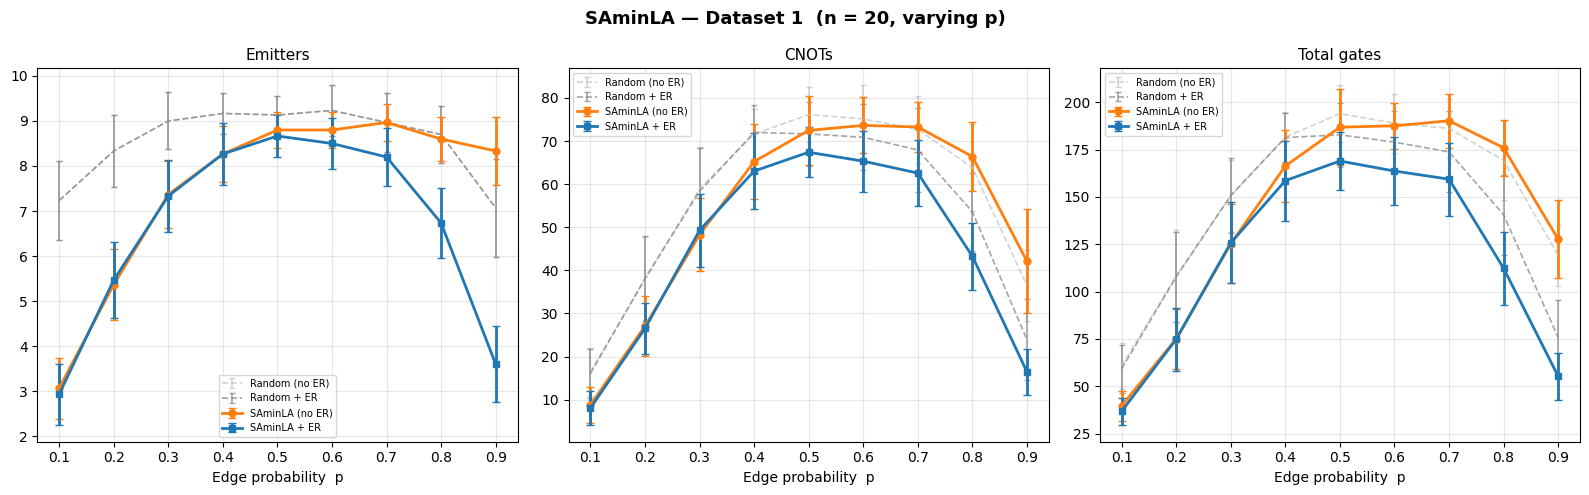

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/saminla_ds1.pdf


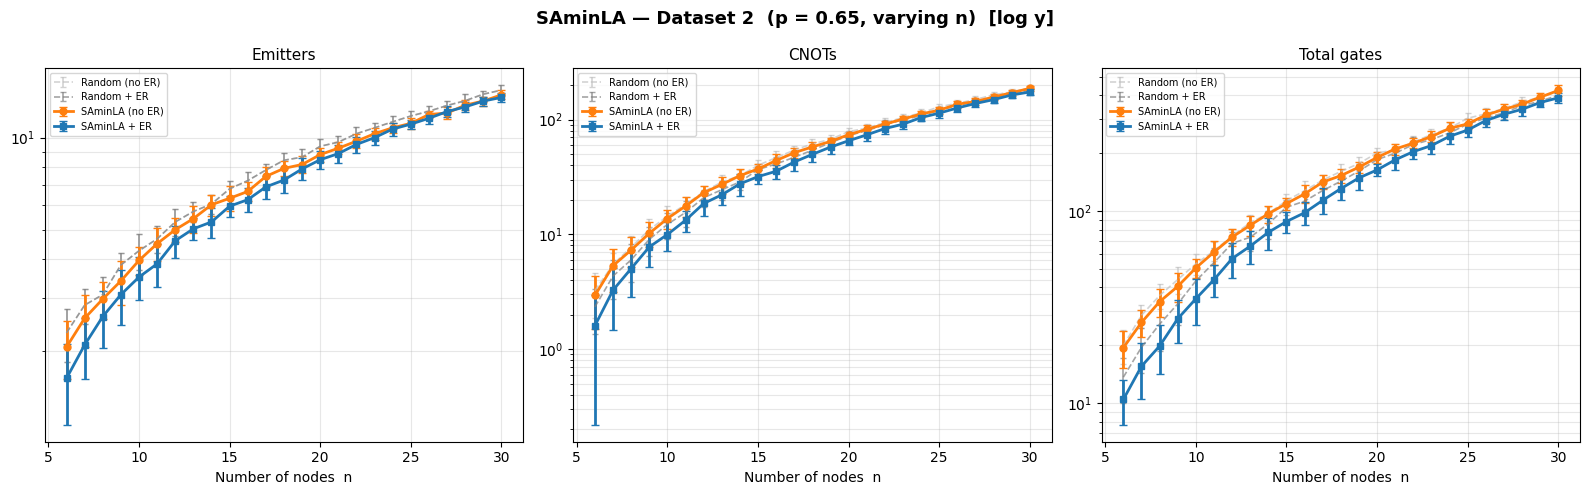

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/saminla_ds2_logy.pdf


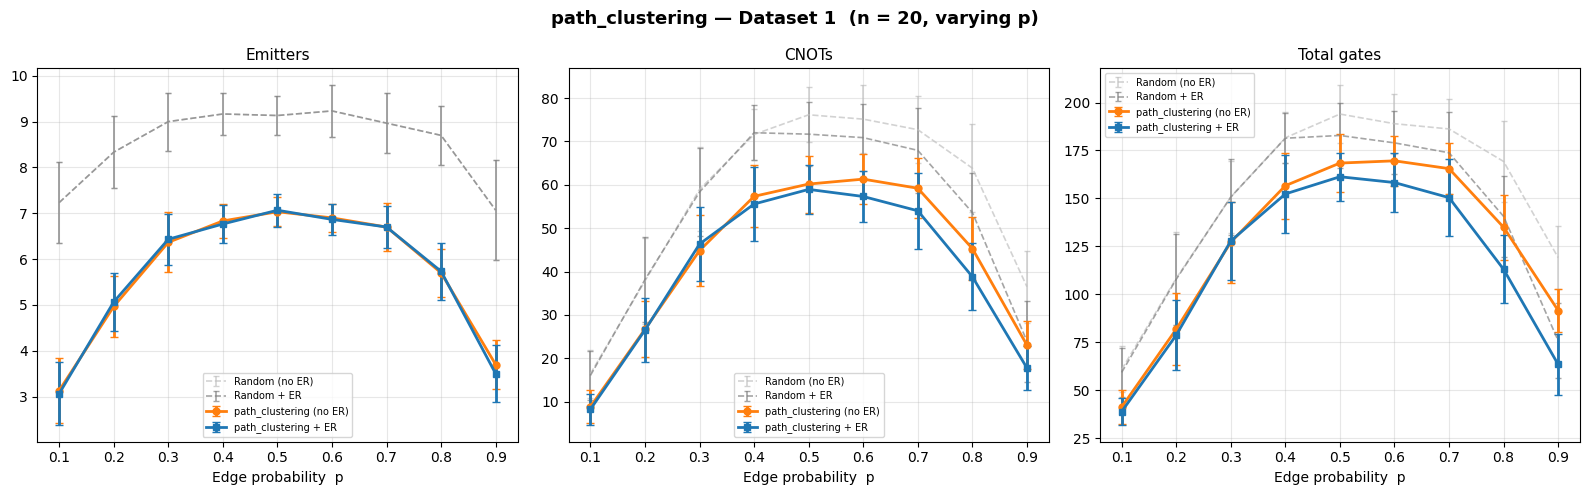

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/path_clustering_ds1.pdf


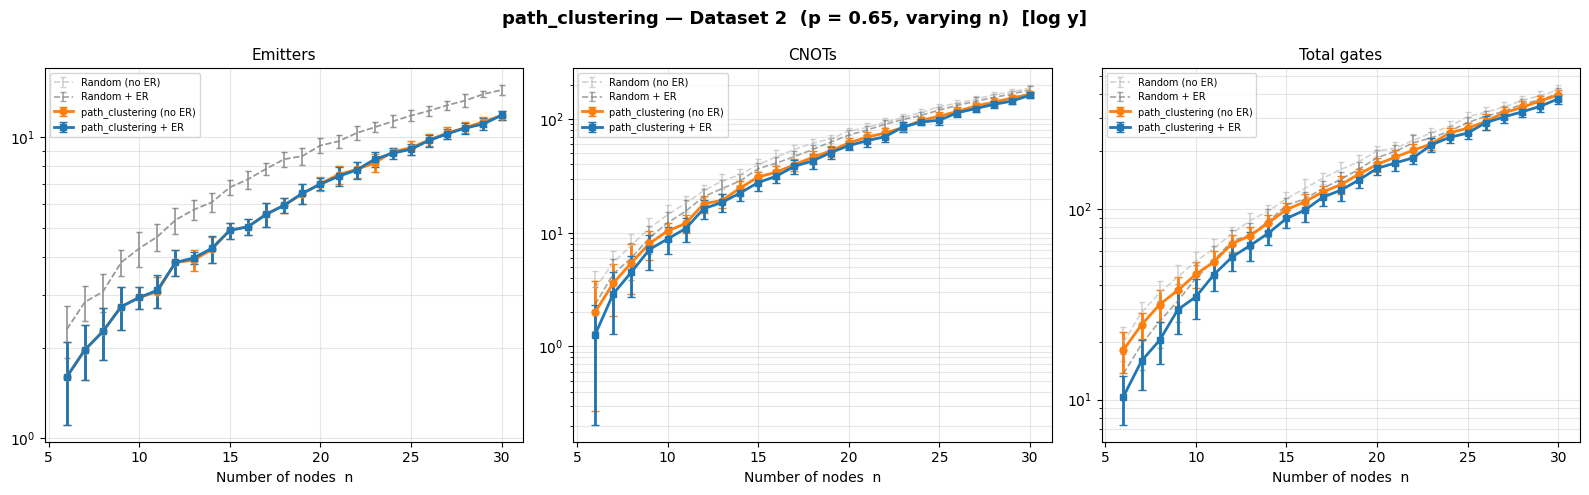

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/path_clustering_ds2_logy.pdf


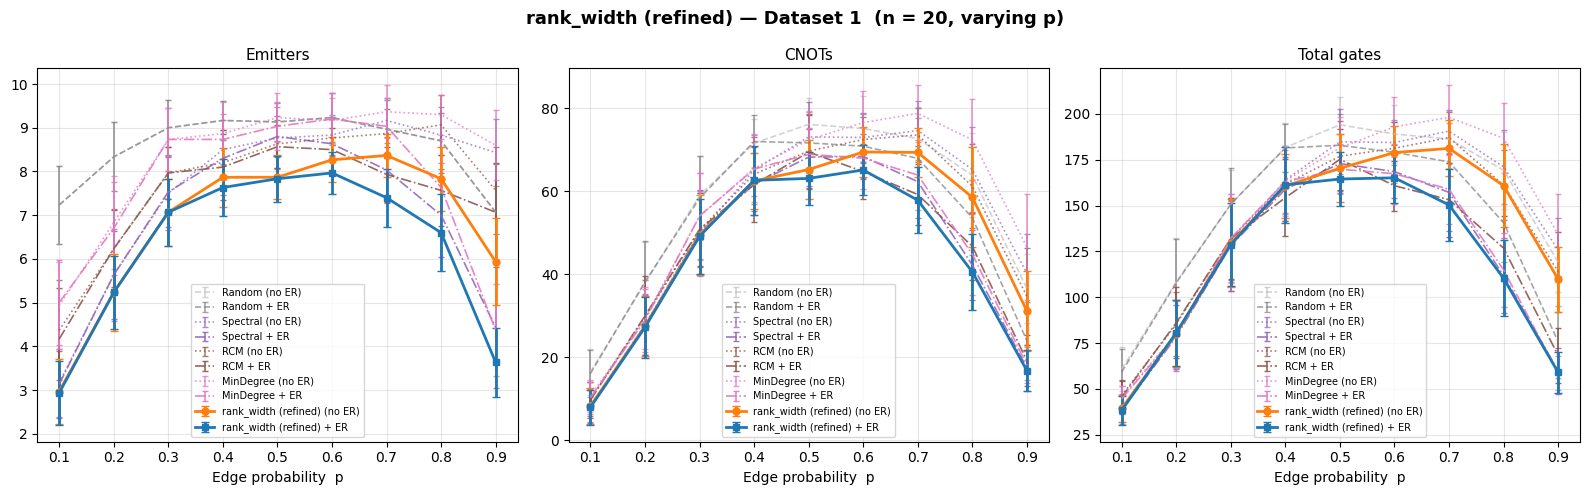

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/rank_width_ds1.pdf


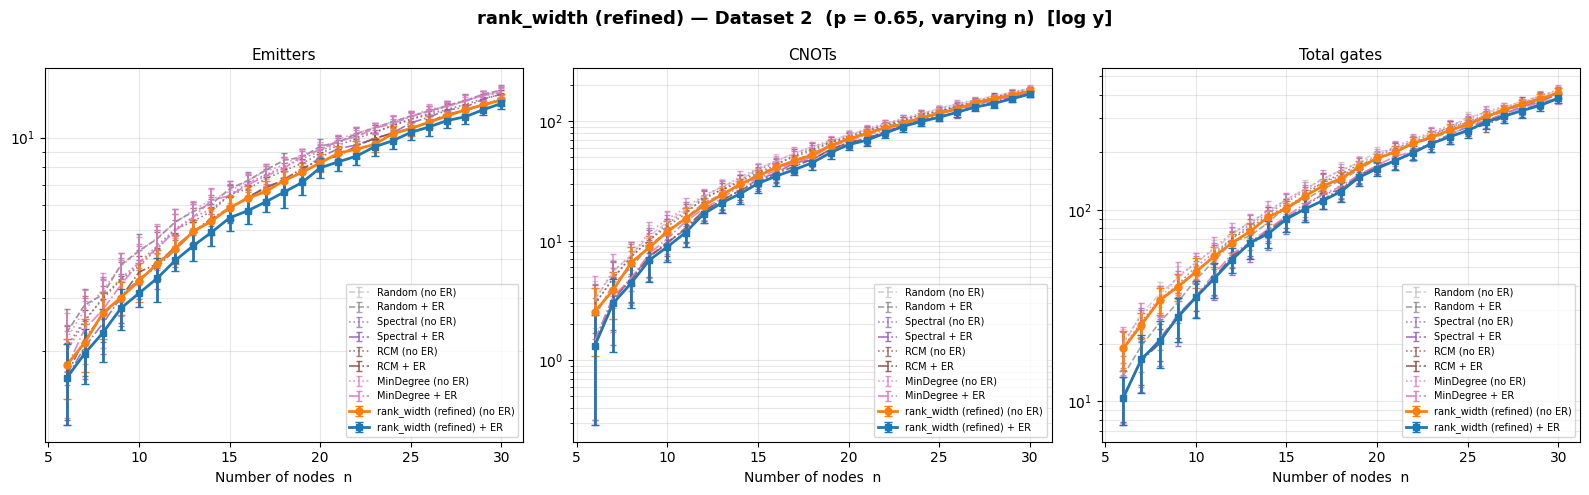

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/rank_width_ds2_logy.pdf


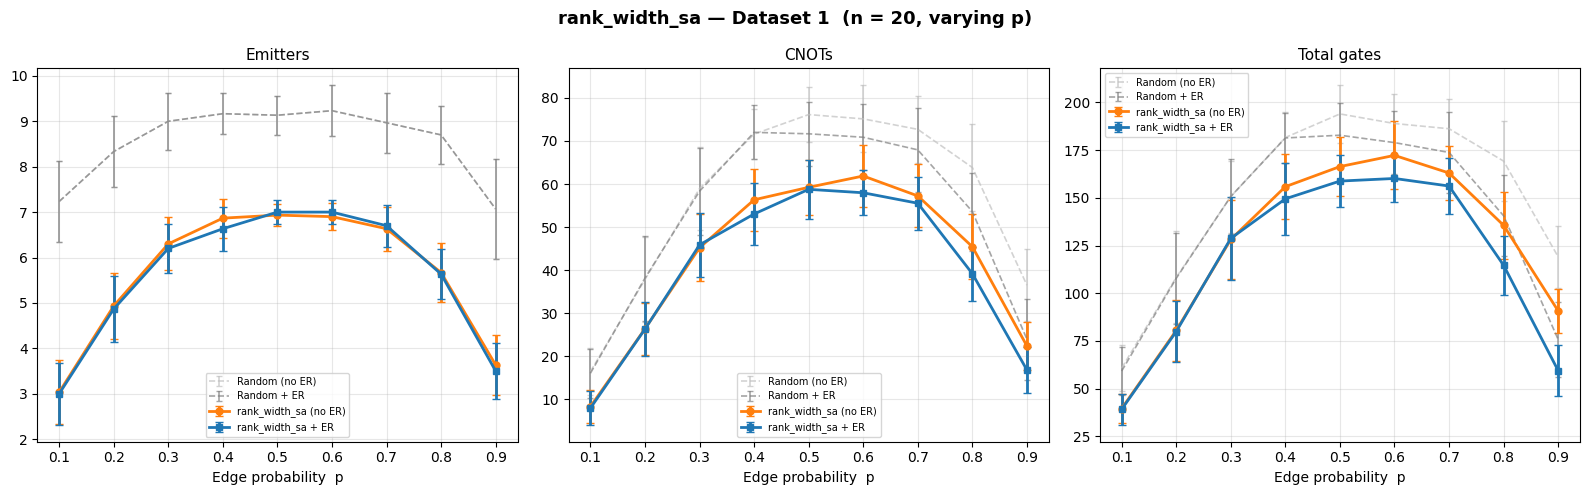

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/rank_width_sa_ds1.pdf


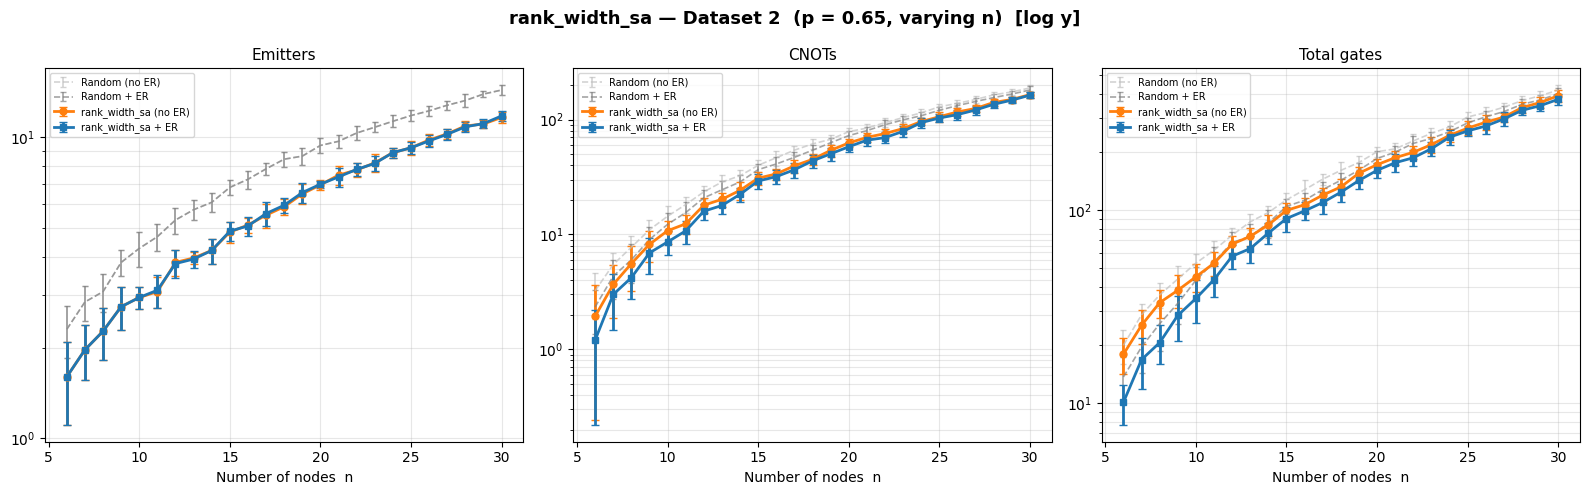

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/rank_width_sa_ds2_logy.pdf


In [50]:

# ── Dataset 1 key-sets ────────────────────────────────────────────────────
probs_ds1  = sorted(set(p for (n, p) in results_ds1_random_label_edge_red.keys() if n == N_FIXED))
keys_ds1   = [(N_FIXED, p) for p in probs_ds1]
ds1_xlabel = "Edge probability  p"
ds1_label  = f"Dataset 1  (n = {N_FIXED}, varying p)"

# ── Dataset 2 key-sets ────────────────────────────────────────────────────
nodes_ds2  = sorted(set(n for (n, p) in results_ds2_random_label_edge_red.keys() if p == P_FIXED))
keys_ds2   = [(n, P_FIXED) for n in nodes_ds2]
ds2_xlabel = "Number of nodes  n"
ds2_label  = f"Dataset 2  (p = {P_FIXED}, varying n)"

# ─────────────────────────────────────────────────────────────────────────────
# 1.  SAminLA
# ─────────────────────────────────────────────────────────────────────────────
for ds_label, x_vals, x_lbl, keys, r_ed, r_no, r_re, r_rn, prefix, log_y in [
    (ds1_label, probs_ds1, ds1_xlabel, keys_ds1,
     results_ds1_saminla_label_edge_red, results_ds1_saminla_label_edge_red_no,
     results_ds1_random_label_edge_red,  results_ds1_random_label_edge_red_no,
     "saminla_ds1", False),
    (ds2_label, nodes_ds2, ds2_xlabel, keys_ds2,
     results_ds2_saminla_label_edge_red, results_ds2_saminla_label_edge_red_no,
     results_ds2_random_label_edge_red,  results_ds2_random_label_edge_red_no,
     "saminla_ds2", True),
]:
    plot_algo_comparison(
        ds_label=ds_label,
        x_values=x_vals, x_label=x_lbl, keys=keys,
        res_edge=r_ed, res_no_edge=r_no,
        res_intermediates=None,
        res_random_edge=r_re, res_random_no=r_rn,
        algo_name="SAminLA",
        save_dir=RESULTS_DIR, save_prefix=prefix,
        log_y=log_y,
    )

# ─────────────────────────────────────────────────────────────────────────────
# 2.  path_clustering
# ─────────────────────────────────────────────────────────────────────────────
for ds_label, x_vals, x_lbl, keys, r_ed, r_no, r_re, r_rn, prefix, log_y in [
    (ds1_label, probs_ds1, ds1_xlabel, keys_ds1,
     results_ds1_path_clustering_label_edge_red, results_ds1_path_clustering_label_edge_red_no,
     results_ds1_random_label_edge_red,           results_ds1_random_label_edge_red_no,
     "path_clustering_ds1", False),
    (ds2_label, nodes_ds2, ds2_xlabel, keys_ds2,
     results_ds2_path_clustering_label_edge_red, results_ds2_path_clustering_label_edge_red_no,
     results_ds2_random_label_edge_red,           results_ds2_random_label_edge_red_no,
     "path_clustering_ds2", True),
]:
    plot_algo_comparison(
        ds_label=ds_label,
        x_values=x_vals, x_label=x_lbl, keys=keys,
        res_edge=r_ed, res_no_edge=r_no,
        res_intermediates=None,
        res_random_edge=r_re, res_random_no=r_rn,
        algo_name="path_clustering",
        save_dir=RESULTS_DIR, save_prefix=prefix,
        log_y=log_y,
    )

# ─────────────────────────────────────────────────────────────────────────────
# 3.  rank_width  (intermediate: Spectral, RCM, MinDegree + Refined as main)
# ─────────────────────────────────────────────────────────────────────────────
rw_intermediates_ds1 = [
    ("Spectral",  results_ds1_rw_spectral_edge_red,  results_ds1_rw_spectral_edge_red_no),
    ("RCM",       results_ds1_rw_rcm_edge_red,       results_ds1_rw_rcm_edge_red_no),
    ("MinDegree", results_ds1_rw_mindegree_edge_red, results_ds1_rw_mindegree_edge_red_no),
]
rw_intermediates_ds2 = [
    ("Spectral",  results_ds2_rw_spectral_edge_red,  results_ds2_rw_spectral_edge_red_no),
    ("RCM",       results_ds2_rw_rcm_edge_red,       results_ds2_rw_rcm_edge_red_no),
    ("MinDegree", results_ds2_rw_mindegree_edge_red, results_ds2_rw_mindegree_edge_red_no),
]

for ds_label, x_vals, x_lbl, keys, r_ed, r_no, r_re, r_rn, intermediates, prefix, log_y in [
    (ds1_label, probs_ds1, ds1_xlabel, keys_ds1,
     results_ds1_rw_refined_edge_red, results_ds1_rw_refined_edge_red_no,
     results_ds1_random_label_edge_red, results_ds1_random_label_edge_red_no,
     rw_intermediates_ds1, "rank_width_ds1", False),
    (ds2_label, nodes_ds2, ds2_xlabel, keys_ds2,
     results_ds2_rw_refined_edge_red, results_ds2_rw_refined_edge_red_no,
     results_ds2_random_label_edge_red, results_ds2_random_label_edge_red_no,
     rw_intermediates_ds2, "rank_width_ds2", True),
]:
    plot_algo_comparison(
        ds_label=ds_label,
        x_values=x_vals, x_label=x_lbl, keys=keys,
        res_edge=r_ed, res_no_edge=r_no,
        res_intermediates=intermediates,
        res_random_edge=r_re, res_random_no=r_rn,
        algo_name="rank_width (refined)",
        save_dir=RESULTS_DIR, save_prefix=prefix,
        log_y=log_y,
    )

# ─────────────────────────────────────────────────────────────────────────────
# 4.  rank_width_sa  (no sub-orderings, single SA output)
# ─────────────────────────────────────────────────────────────────────────────
for ds_label, x_vals, x_lbl, keys, r_ed, r_no, r_re, r_rn, prefix, log_y in [
    (ds1_label, probs_ds1, ds1_xlabel, keys_ds1,
     results_ds1_rw_sa_edge_red, results_ds1_rw_sa_edge_red_no,
     results_ds1_random_label_edge_red, results_ds1_random_label_edge_red_no,
     "rank_width_sa_ds1", False),
    (ds2_label, nodes_ds2, ds2_xlabel, keys_ds2,
     results_ds2_rw_sa_edge_red, results_ds2_rw_sa_edge_red_no,
     results_ds2_random_label_edge_red, results_ds2_random_label_edge_red_no,
     "rank_width_sa_ds2", True),
]:
    plot_algo_comparison(
        ds_label=ds_label,
        x_values=x_vals, x_label=x_lbl, keys=keys,
        res_edge=r_ed, res_no_edge=r_no,
        res_intermediates=None,
        res_random_edge=r_re, res_random_no=r_rn,
        algo_name="rank_width_sa",
        save_dir=RESULTS_DIR, save_prefix=prefix,
        log_y=log_y,
    )


## Best version of each algorithm vs random labelling

For every algorithm we pick its **best** variant (i.e. with edge reduction, and the refined ordering for rank_width).
Both datasets are shown side-by-side. The random labelling (with and without ER) is the grey baseline.

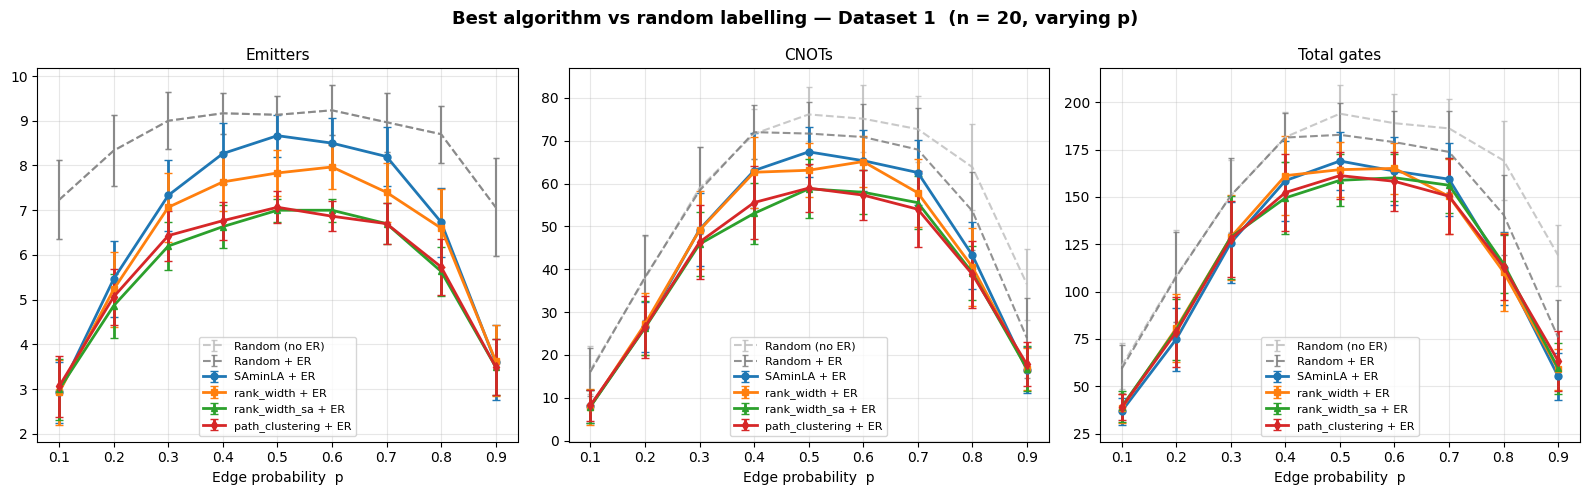

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/best_algos_vs_random_ds1.pdf


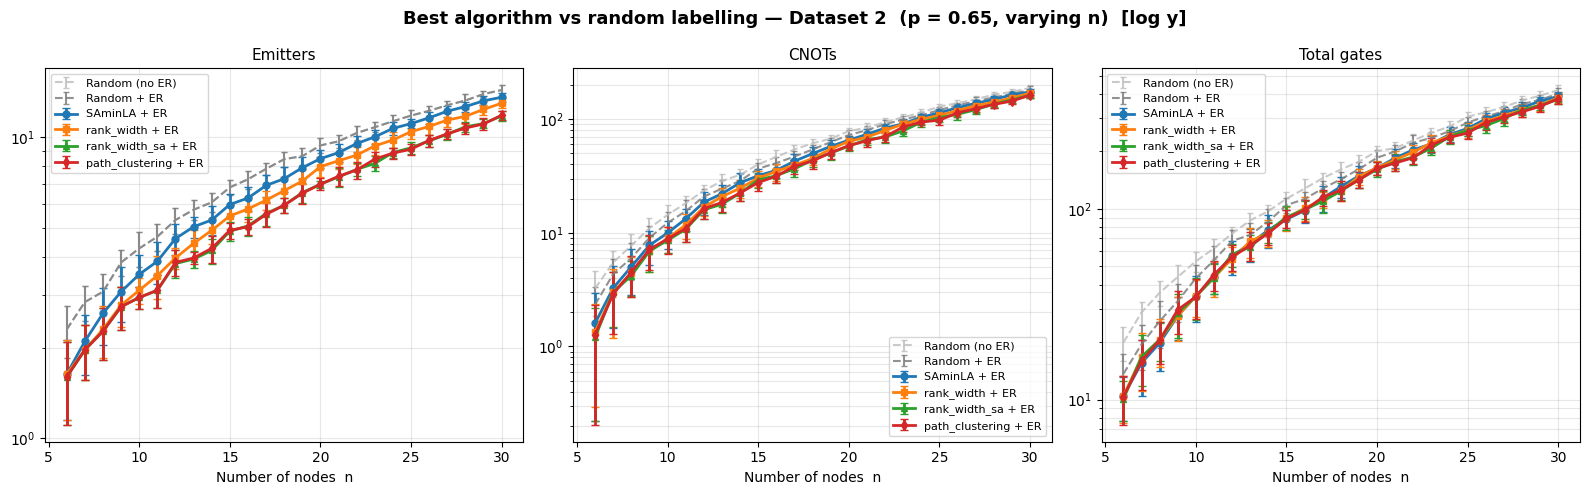

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/best_algos_vs_random_ds2_logy.pdf


In [51]:

# ── Best-variant catalogue (always "with edge reduction", refined where applicable) ──
# Each entry: (display_label, colour, marker, ds1_dict, ds2_dict)
best_algos = [
    ("SAminLA",          "tab:blue",   "o-",
     results_ds1_saminla_label_edge_red,          results_ds2_saminla_label_edge_red),
    ("rank_width",       "tab:orange", "s-",
     results_ds1_rw_refined_edge_red,             results_ds2_rw_refined_edge_red),
    ("rank_width_sa",    "tab:green",  "^-",
     results_ds1_rw_sa_edge_red,                  results_ds2_rw_sa_edge_red),
    ("path_clustering",  "tab:red",    "d-",
     results_ds1_path_clustering_label_edge_red,  results_ds2_path_clustering_label_edge_red),
]

metrics = [
    ("emitters_mean", "emitters_std", "Emitters"),
    ("cnots_mean",    "cnots_std",    "CNOTs"),
    ("gates_mean",    "gates_std",    "Total gates"),
]

for ds_idx, (ds_label, x_vals, x_lbl, keys, r_rand_ed, r_rand_no, log_y) in enumerate([
    (f"Dataset 1  (n = {N_FIXED}, varying p)",
     probs_ds1, "Edge probability  p", keys_ds1,
     results_ds1_random_label_edge_red, results_ds1_random_label_edge_red_no,
     False),
    (f"Dataset 2  (p = {P_FIXED}, varying n)",
     nodes_ds2, "Number of nodes  n", keys_ds2,
     results_ds2_random_label_edge_red, results_ds2_random_label_edge_red_no,
     True),
], start=1):

    log_suffix = "  [log y]" if log_y else ""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(f"Best algorithm vs random labelling — {ds_label}{log_suffix}",
                 fontsize=13, fontweight="bold")

    for ax, (m_mean, m_std, m_title) in zip(axes, metrics):
        # Random baselines
        m, s = _extract(r_rand_no,  keys, m_mean, m_std)
        ax.errorbar(x_vals, m, yerr=s, fmt="--", color="silver",   alpha=0.85,
                    capsize=2, lw=1.5, label="Random (no ER)")
        m, s = _extract(r_rand_ed, keys, m_mean, m_std)
        ax.errorbar(x_vals, m, yerr=s, fmt="--", color="tab:gray", alpha=0.85,
                    capsize=2, lw=1.5, label="Random + ER")

        # Best variant of each algorithm
        for alabel, acolor, amarker, ds1_d, ds2_d in best_algos:
            res = ds1_d if ds_idx == 1 else ds2_d
            m, s = _extract(res, keys, m_mean, m_std)
            ax.errorbar(x_vals, m, yerr=s, fmt=amarker, color=acolor,
                        capsize=3, lw=2, ms=5, label=f"{alabel} + ER")

        ax.set_title(m_title, fontsize=11)
        ax.set_xlabel(x_lbl, fontsize=10)
        if log_y:
            ax.set_yscale("log")
            ax.grid(True, alpha=0.3, which="both")
        else:
            ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    log_tag = "_logy" if log_y else ""
    fname = f"best_algos_vs_random_ds{ds_idx}{log_tag}.pdf"
    fpath = os.path.join(RESULTS_DIR, fname)
    plt.savefig(fpath, dpi=150)
    plt.show()
    print(f"Saved → {fpath}")


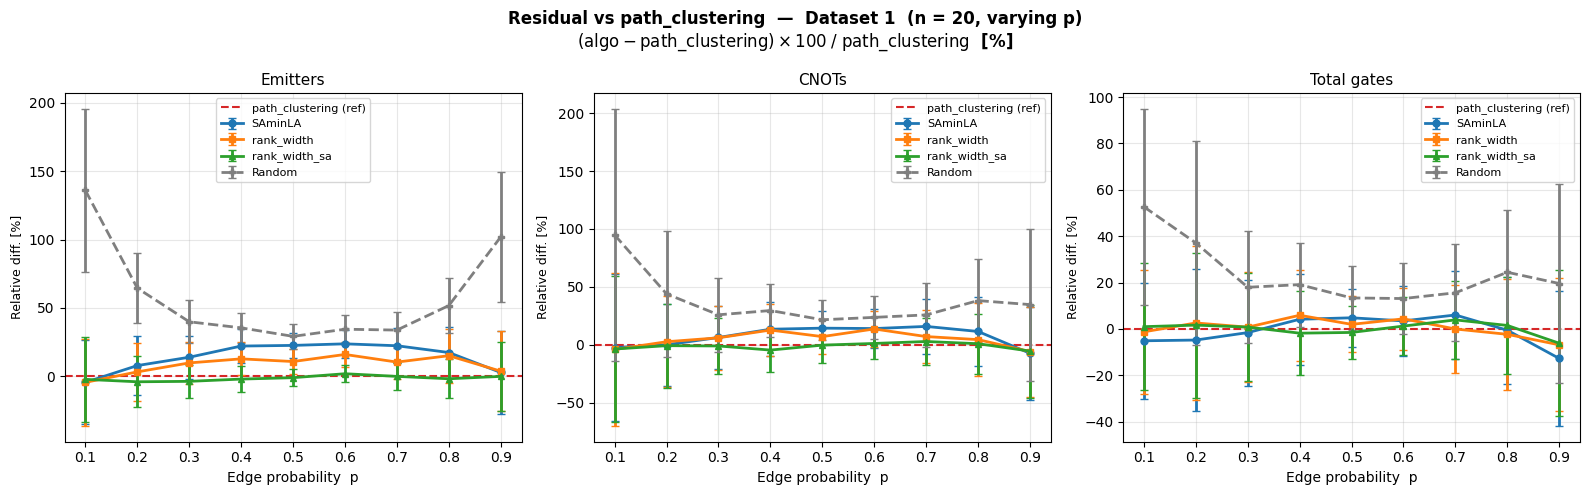

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/residual_vs_path_clustering_ds1.pdf


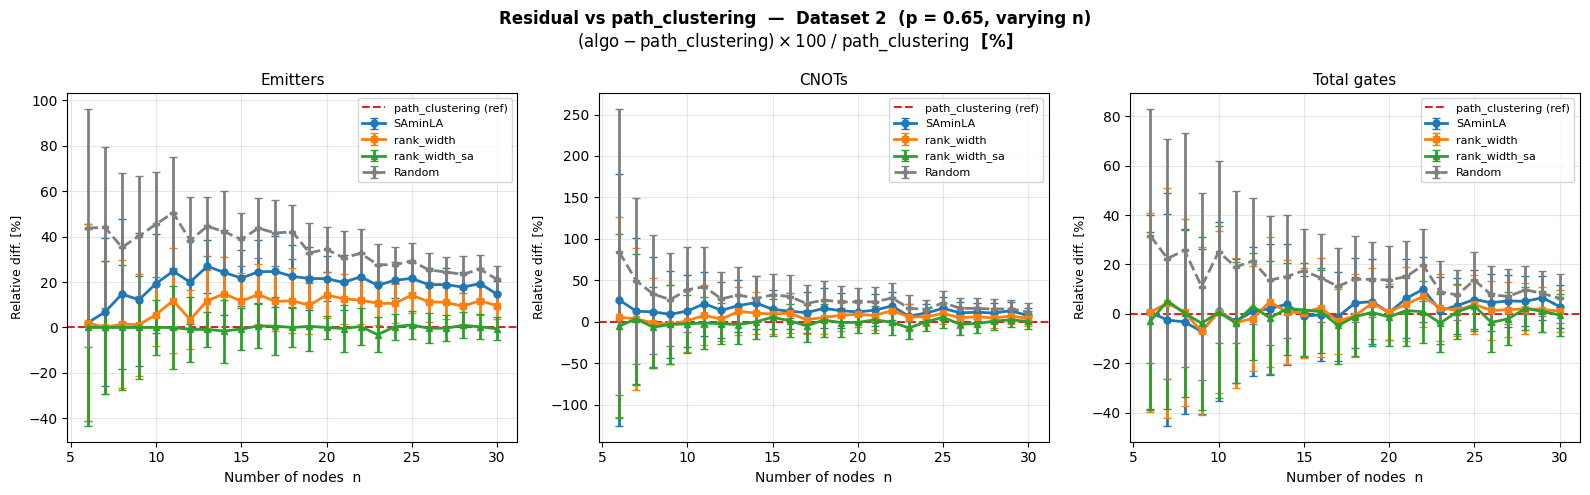

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/residual_vs_path_clustering_ds2.pdf


In [ ]:
# ── Residual difference relative to path_clustering: (algo - path_clustering)*100 / path_clustering ──
#
# R = (a - b) * 100 / b,  where a = algo mean, b = path_clustering mean
#
# Full first-order error propagation (a and b are independent):
#   σ_R = (100/b) * sqrt(σ_a² + (a/b)² * σ_b²)

# path_clustering is the reference
ref_ds1 = results_ds1_path_clustering_label_edge_red
ref_ds2 = results_ds2_path_clustering_label_edge_red

# Algorithms to compare (excluding path_clustering itself)
residual_algos = [
    ("SAminLA",       "tab:blue",   "o-",
     results_ds1_saminla_label_edge_red,   results_ds2_saminla_label_edge_red),
    ("rank_width",    "tab:orange", "s-",
     results_ds1_rw_refined_edge_red,      results_ds2_rw_refined_edge_red),
    ("rank_width_sa", "tab:green",  "^-",
     results_ds1_rw_sa_edge_red,           results_ds2_rw_sa_edge_red),
    ("Random",        "tab:gray",   "P--",
     results_ds1_random_label_edge_red,    results_ds2_random_label_edge_red),
]

metrics = [
    ("emitters_mean", "emitters_std", "Emitters"),
    ("cnots_mean",    "cnots_std",    "CNOTs"),
    ("gates_mean",    "gates_std",    "Total gates"),
]

for ds_idx, (ds_label, x_vals, x_lbl, keys, ref, log_y) in enumerate([
    (f"Dataset 1  (n = {N_FIXED}, varying p)",
     probs_ds1, "Edge probability  p", keys_ds1, ref_ds1, False),
    (f"Dataset 2  (p = {P_FIXED}, varying n)",
     nodes_ds2, "Number of nodes  n", keys_ds2, ref_ds2, False),
], start=1):

    log_suffix = "  [log y]" if log_y else ""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(
        f"Residual vs path_clustering  —  {ds_label}{log_suffix}\n"
        r"$({\rm algo} - {\rm path\_clustering})\times 100\;/\;{\rm path\_clustering}$  [%]",
        fontsize=12, fontweight="bold"
    )

    # Pre-extract reference mean and std for each metric
    ref_means = {}
    ref_stds  = {}
    for m_mean, m_std, _ in metrics:
        rm, rs = _extract(ref, keys, m_mean, m_std)
        ref_means[m_mean] = np.array(rm)
        ref_stds[m_mean]  = np.array(rs)

    for ax, (m_mean, m_std, m_title) in zip(axes, metrics):
        ref_m = ref_means[m_mean]
        ref_s = ref_stds[m_mean]

        # horizontal zero line (= path_clustering baseline)
        ax.axhline(0, color="tab:red", lw=1.5, ls="--", label="path_clustering (ref)")

        for alabel, acolor, amarker, ds1_d, ds2_d in residual_algos:
            res = ds1_d if ds_idx == 1 else ds2_d
            algo_m, algo_s = _extract(res, keys, m_mean, m_std)
            algo_m = np.array(algo_m)
            algo_s = np.array(algo_s)

            # Residual mean
            residual_m = (algo_m - ref_m) * 100.0 / ref_m

            # Full first-order propagation:
            #   σ_R = (100/b) * sqrt(σ_a² + (a/b)² * σ_b²)
            residual_s = (100.0 / ref_m) * np.sqrt(
                algo_s**2 + (algo_m / ref_m)**2 * ref_s**2
            )

            ax.errorbar(x_vals, residual_m, yerr=residual_s,
                        fmt=amarker, color=acolor,
                        capsize=3, lw=2, ms=5, label=alabel)

        ax.set_title(m_title, fontsize=11)
        ax.set_xlabel(x_lbl, fontsize=10)
        ax.set_ylabel("Relative diff. [%]", fontsize=9)
        if log_y:
            ax.set_yscale("symlog", linthresh=1)
            ax.grid(True, alpha=0.3, which="both")
        else:
            ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    log_tag = "_logy" if log_y else ""
    fname = f"residual_vs_path_clustering_ds{ds_idx}{log_tag}.pdf"
    fpath = os.path.join(RESULTS_DIR, fname)
    plt.savefig(fpath, dpi=150)
    plt.show()
    print(f"Saved → {fpath}")


## Runtime for each algorithm

In [36]:
# Runtime data will be saved to the same step2_dataset directory (DATASET_DIR)
import time

### Runtime vs graph density — Dataset 1 (fixed n=20, varying p)

For each `(n, p)` setting and each graph we:
1. Apply edge reduction
2. Time each of the 4 ordering algorithms on the **reduced** graph
3. Record per-graph wall-clock times and compute mean/std per setting

Algorithms:
- **SAminLA** — `run_optimization(G, opt_CNOT=True)` (full pipeline: edge_red already done, so `edge_reduction=False, minLA=True`)
- **rank_width (refined)** — `linear_rank_width(G, refine=True)`
- **rank_width_sa** — `linear_rank_width_sa(G, refine=True)`
- **path_clustering** — `path_clustering_lrw(G, refine=True)`

In [ ]:
# ── Runtime – Dataset 1: fixed n=20, scan over probability ─────────────

runtime_ds1_saminla       = {}
runtime_ds1_rw_refined    = {}
runtime_ds1_rw_sa         = {}
runtime_ds1_path_clustering = {}

for (n, p), graphs in sorted(ds1.items(), key=lambda x: x[0][1]):
    t_saminla = []
    t_rw      = []
    t_rw_sa   = []
    t_path    = []

    print(f"  n={n}, p={p}  ({len(graphs)} graphs) ... ", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        # --- SAminLA ---
        t0 = time.perf_counter()
        _ = run_optimization(G_sim)
        t_saminla.append(time.perf_counter() - t0)

        # --- rank_width (refined) ---
        t0 = time.perf_counter()
        _ = linear_rank_width(G_sim)
        t_rw.append(time.perf_counter() - t0)

        # --- rank_width_sa ---
        t0 = time.perf_counter()
        _ = linear_rank_width_sa(G_sim)
        t_rw_sa.append(time.perf_counter() - t0)

        # --- path_clustering ---
        t0 = time.perf_counter()
        _ = path_clustering_lrw(G_sim)
        t_path.append(time.perf_counter() - t0)

    for label, times_list, res_dict in [
        ("SAminLA",          t_saminla,  runtime_ds1_saminla),
        ("rw_refined",       t_rw,       runtime_ds1_rw_refined),
        ("rw_sa",            t_rw_sa,    runtime_ds1_rw_sa),
        ("path_clustering",  t_path,     runtime_ds1_path_clustering),
    ]:
        arr = np.array(times_list)
        res_dict[(n, p)] = {
            "time_mean": arr.mean(),
            "time_std":  arr.std(),
            "time_raw":  arr,
        }
        print(f"    {label:>18s}: {arr.mean():.3f} ± {arr.std():.3f} s")

# Save all four
for name, res_dict in [
    ("runtime_ds1_saminla",          runtime_ds1_saminla),
    ("runtime_ds1_rw_refined",       runtime_ds1_rw_refined),
    ("runtime_ds1_rw_sa",            runtime_ds1_rw_sa),
    ("runtime_ds1_path_clustering",  runtime_ds1_path_clustering),
]:
    fpath = os.path.join(RESULTS_DIR, f"{name}.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n=20, p=0.1  (30 graphs) ... 
               SAminLA: 1.445 ± 0.217 s
            rw_refined: 1.626 ± 0.466 s
                 rw_sa: 5.541 ± 0.107 s
       path_clustering: 5.088 ± 1.941 s
  n=20, p=0.2  (30 graphs) ... 
               SAminLA: 2.348 ± 0.283 s
            rw_refined: 2.588 ± 0.545 s
                 rw_sa: 5.810 ± 0.081 s
       path_clustering: 4.441 ± 0.074 s
  n=20, p=0.3  (30 graphs) ... 
               SAminLA: 3.280 ± 0.320 s
            rw_refined: 3.039 ± 0.387 s
                 rw_sa: 5.964 ± 0.067 s
       path_clustering: 4.552 ± 0.034 s
  n=20, p=0.4  (30 graphs) ... 
               SAminLA: 4.027 ± 0.273 s
            rw_refined: 3.237 ± 0.282 s
                 rw_sa: 6.052 ± 0.061 s
       path_clustering: 4.620 ± 0.050 s
  n=20, p=0.5  (30 graphs) ... 
               SAminLA: 4.140 ± 0.231 s
            rw_refined: 3.470 ± 0.625 s
                 rw_sa: 6.065 ± 0.039 s
       path_clustering: 4.641 ± 0.060 s
  n=20, p=0.6  (30 graphs) ... 
        

### Runtime vs number of nodes — Dataset 2 (fixed p=0.65, varying n)

Same 4 algorithms, now scanning over graph size `n = 6..40`.

In [41]:
# ── Runtime – Dataset 2: fixed p=0.65, scan over number of vertices ────

runtime_ds2_saminla       = {}
runtime_ds2_rw_refined    = {}
runtime_ds2_rw_sa         = {}
runtime_ds2_path_clustering = {}

for (n, p), graphs in sorted(ds2.items(), key=lambda x: x[0][0]):
    t_saminla = []
    t_rw      = []
    t_rw_sa   = []
    t_path    = []

    print(f"  n={n:>2d}, p={p}  ({len(graphs)} graphs) ... ", flush=True)

    for G in graphs:
        G_sim = edge_reduction_func(G)

        # --- SAminLA ---
        t0 = time.perf_counter()
        _ = run_optimization(G_sim)
        t_saminla.append(time.perf_counter() - t0)

        # --- rank_width (refined) ---
        t0 = time.perf_counter()
        _ = linear_rank_width(G_sim)
        t_rw.append(time.perf_counter() - t0)

        # --- rank_width_sa ---
        t0 = time.perf_counter()
        _ = linear_rank_width_sa(G_sim)
        t_rw_sa.append(time.perf_counter() - t0)

        # --- path_clustering ---
        t0 = time.perf_counter()
        _ = path_clustering_lrw(G_sim)
        t_path.append(time.perf_counter() - t0)

    for label, times_list, res_dict in [
        ("SAminLA",          t_saminla,  runtime_ds2_saminla),
        ("rw_refined",       t_rw,       runtime_ds2_rw_refined),
        ("rw_sa",            t_rw_sa,    runtime_ds2_rw_sa),
        ("path_clustering",  t_path,     runtime_ds2_path_clustering),
    ]:
        arr = np.array(times_list)
        res_dict[(n, p)] = {
            "time_mean": arr.mean(),
            "time_std":  arr.std(),
            "time_raw":  arr,
        }
        print(f"    {label:>18s}: {arr.mean():.3f} ± {arr.std():.3f} s")

# Save all four
for name, res_dict in [
    ("runtime_ds2_saminla",          runtime_ds2_saminla),
    ("runtime_ds2_rw_refined",       runtime_ds2_rw_refined),
    ("runtime_ds2_rw_sa",            runtime_ds2_rw_sa),
    ("runtime_ds2_path_clustering",  runtime_ds2_path_clustering),
]:
    fpath = os.path.join(RESULTS_DIR, f"{name}.pkl")
    with open(fpath, "wb") as f:
        pickle.dump(res_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved → {fpath}  ({os.path.getsize(fpath)/1024:.1f} KB)")

  n= 6, p=0.65  (30 graphs) ... 
               SAminLA: 0.421 ± 0.041 s
            rw_refined: 0.047 ± 0.002 s
                 rw_sa: 1.541 ± 0.027 s
       path_clustering: 1.179 ± 0.022 s
  n= 7, p=0.65  (30 graphs) ... 
               SAminLA: 0.514 ± 0.048 s
            rw_refined: 0.091 ± 0.005 s
                 rw_sa: 1.780 ± 0.022 s
       path_clustering: 1.359 ± 0.015 s
  n= 8, p=0.65  (30 graphs) ... 
               SAminLA: 0.613 ± 0.068 s
            rw_refined: 0.166 ± 0.021 s
                 rw_sa: 2.028 ± 0.043 s
       path_clustering: 1.542 ± 0.019 s
  n= 9, p=0.65  (30 graphs) ... 
               SAminLA: 0.765 ± 0.075 s
            rw_refined: 0.261 ± 0.033 s
                 rw_sa: 2.285 ± 0.026 s
       path_clustering: 1.750 ± 0.034 s
  n=10, p=0.65  (30 graphs) ... 
               SAminLA: 0.897 ± 0.080 s
            rw_refined: 0.403 ± 0.053 s
                 rw_sa: 2.546 ± 0.019 s
       path_clustering: 1.946 ± 0.021 s
  n=11, p=0.65  (30 graphs) ... 
  

### Plot — Runtime vs edge probability (Dataset 1, n=20)

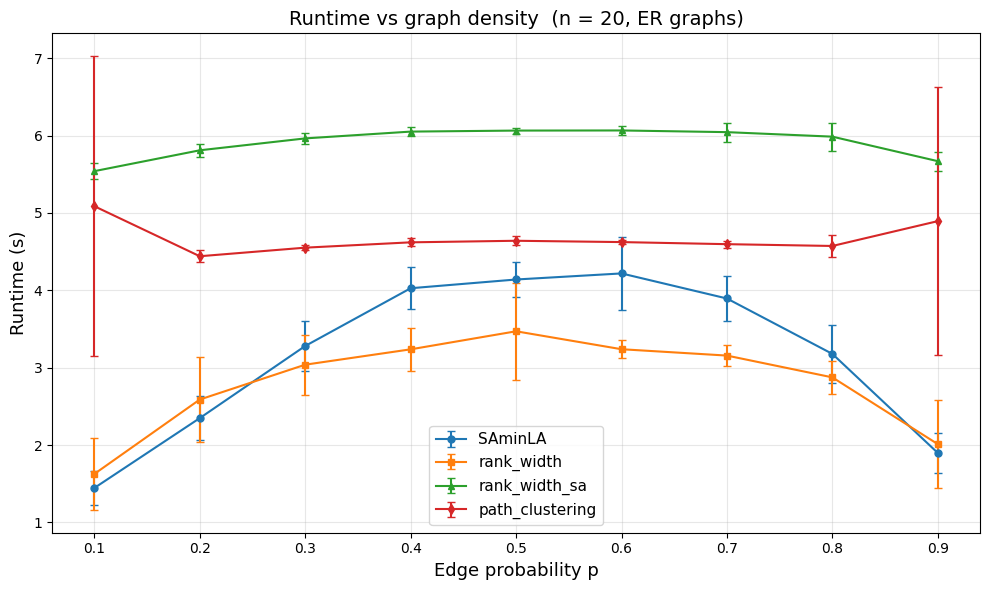

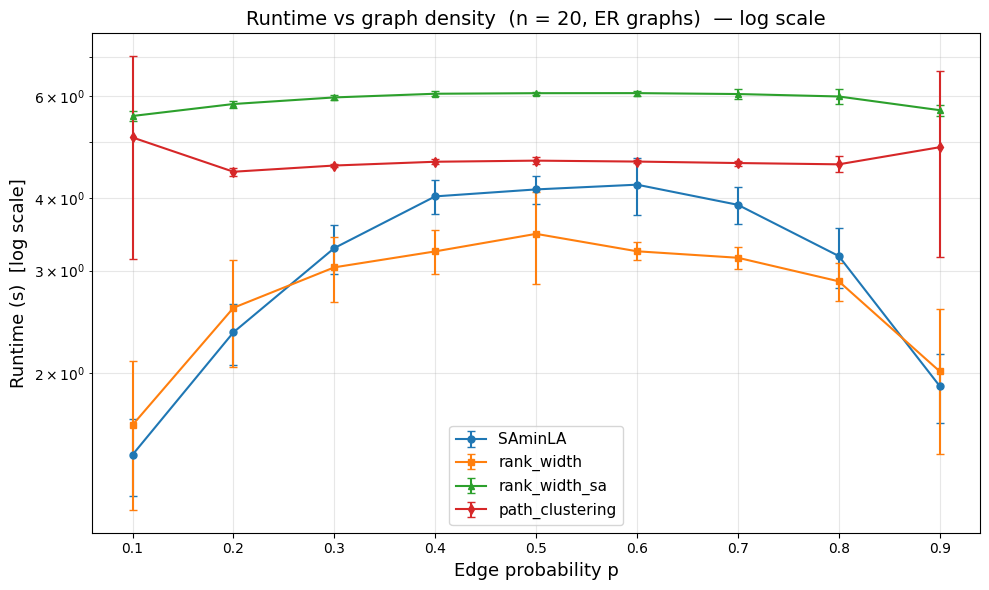

In [44]:
# ── Plot: Runtime vs edge probability p  (Dataset 1, fixed n=N_FIXED) ───────

algo_styles = [
    ("SAminLA",          runtime_ds1_saminla,          "o-",  "tab:blue"),
    ("rank_width",       runtime_ds1_rw_refined,       "s-",  "tab:orange"),
    ("rank_width_sa",    runtime_ds1_rw_sa,            "^-",  "tab:green"),
    ("path_clustering",  runtime_ds1_path_clustering,  "d-",  "tab:red"),
]

# Extract sorted probability values present for n=N_FIXED in all algorithms (intersection)
# This ensures we only plot probabilities that exist for every algorithm's results,
# avoiding KeyError when an algorithm has missing (n,p) entries.
all_p_sets = [set(p for (n, p) in res_dict.keys() if n == N_FIXED) for (_, res_dict, _, _) in algo_styles]
if all_p_sets:
    probs = sorted(set.intersection(*all_p_sets))
else:
    probs = []
if not probs:
    raise RuntimeError(f'No common probability values found for n={N_FIXED} across algorithms')

fig, ax = plt.subplots(figsize=(10, 6))

for label, res_dict, marker, color in algo_styles:
    means = [res_dict[(N_FIXED, p)]["time_mean"] for p in probs]
    stds  = [res_dict[(N_FIXED, p)]["time_std"]  for p in probs]
    ax.errorbar(probs, means, yerr=stds, fmt=marker, color=color,
                label=label, capsize=3, markersize=5, linewidth=1.5)

ax.set_xlabel("Edge probability p", fontsize=13)
ax.set_ylabel("Runtime (s)", fontsize=13)
ax.set_title(f"Runtime vs graph density  (n = {N_FIXED}, ER graphs)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "runtime_vs_density_ds1.pdf"), dpi=150)
plt.show()

# Also log-scale version
fig, ax = plt.subplots(figsize=(10, 6))

for label, res_dict, marker, color in algo_styles:
    means = [res_dict[(N_FIXED, p)]["time_mean"] for p in probs]
    stds  = [res_dict[(N_FIXED, p)]["time_std"]  for p in probs]
    ax.errorbar(probs, means, yerr=stds, fmt=marker, color=color,
                label=label, capsize=3, markersize=5, linewidth=1.5)

ax.set_xlabel("Edge probability p", fontsize=13)
ax.set_ylabel("Runtime (s)  [log scale]", fontsize=13)
ax.set_title(f"Runtime vs graph density  (n = {N_FIXED}, ER graphs)  — log scale", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "runtime_vs_density_ds1_log.pdf"), dpi=150)
plt.show()


### Plot — Runtime vs number of nodes (Dataset 2, p=0.65)

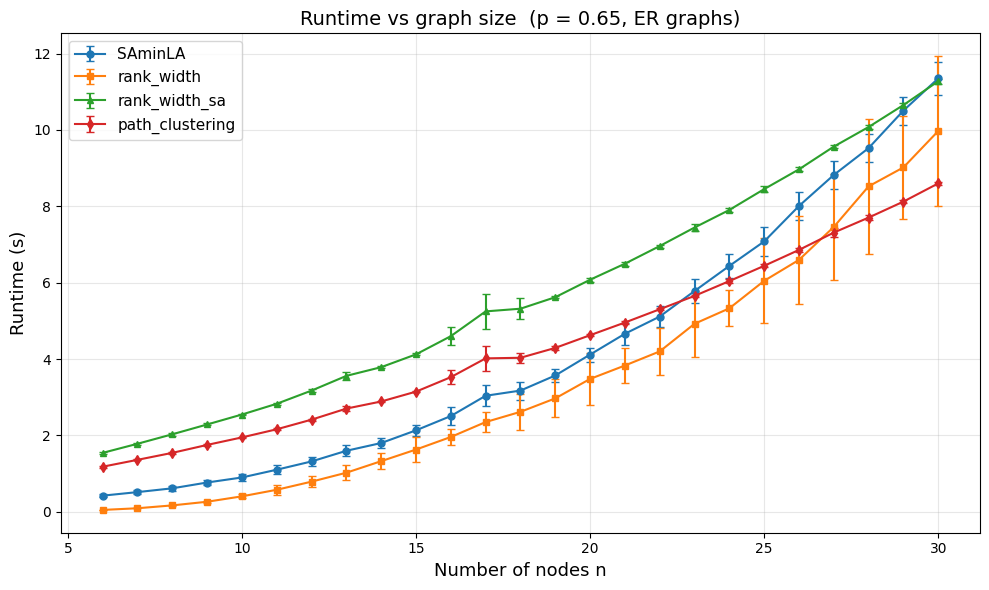

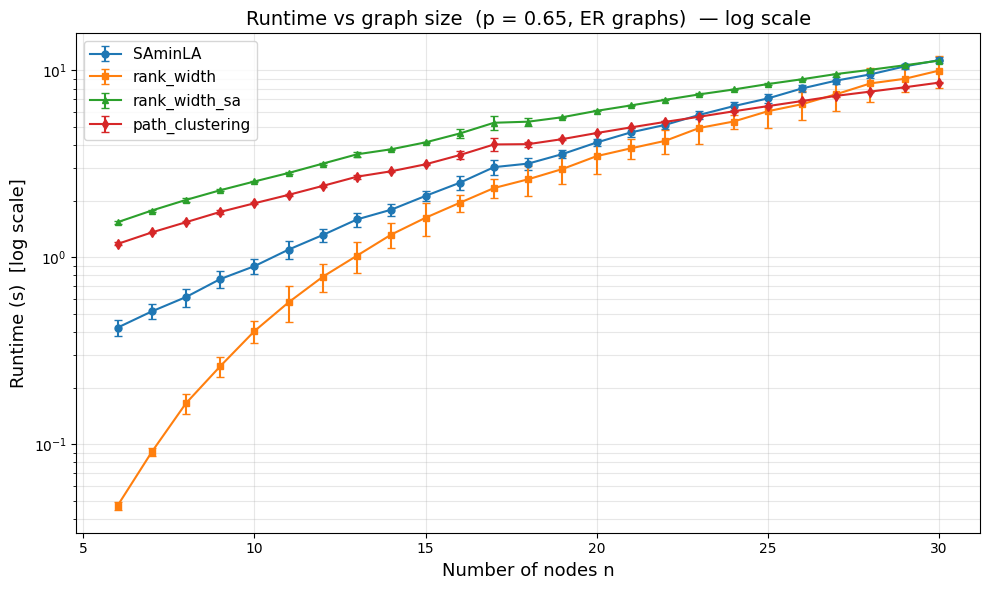

In [45]:
# ── Plot: Runtime vs number of nodes n  (Dataset 2, fixed p=P_FIXED) ──────

algo_styles_ds2 = [
    ("SAminLA",          runtime_ds2_saminla,          "o-",  "tab:blue"),
    ("rank_width",       runtime_ds2_rw_refined,       "s-",  "tab:orange"),
    ("rank_width_sa",    runtime_ds2_rw_sa,            "^-",  "tab:green"),
    ("path_clustering",  runtime_ds2_path_clustering,  "d-",  "tab:red"),
]

# Extract sorted node counts present for p=P_FIXED in all algorithms (intersection)
all_n_sets = [set(n for (n, p) in res_dict.keys() if p == P_FIXED) for (_, res_dict, _, _) in algo_styles_ds2]
if all_n_sets:
    node_counts = sorted(set.intersection(*all_n_sets))
else:
    node_counts = []
if not node_counts:
    raise RuntimeError(f'No common node counts found for p={P_FIXED} across algorithms')

fig, ax = plt.subplots(figsize=(10, 6))

for label, res_dict, marker, color in algo_styles_ds2:
    means = [res_dict[(n, P_FIXED)]["time_mean"] for n in node_counts]
    stds  = [res_dict[(n, P_FIXED)]["time_std"]  for n in node_counts]
    ax.errorbar(node_counts, means, yerr=stds, fmt=marker, color=color,
                label=label, capsize=3, markersize=5, linewidth=1.5)

ax.set_xlabel("Number of nodes n", fontsize=13)
ax.set_ylabel("Runtime (s)", fontsize=13)
ax.set_title(f"Runtime vs graph size  (p = {P_FIXED}, ER graphs)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "runtime_vs_nodes_ds2.pdf"), dpi=150)
plt.show()

# Also log-scale version
fig, ax = plt.subplots(figsize=(10, 6))

for label, res_dict, marker, color in algo_styles_ds2:
    means = [res_dict[(n, P_FIXED)]["time_mean"] for n in node_counts]
    stds  = [res_dict[(n, P_FIXED)]["time_std"]  for n in node_counts]
    ax.errorbar(node_counts, means, yerr=stds, fmt=marker, color=color,
                label=label, capsize=3, markersize=5, linewidth=1.5)

ax.set_xlabel("Number of nodes n", fontsize=13)
ax.set_ylabel("Runtime (s)  [log scale]", fontsize=13)
ax.set_title(f"Runtime vs graph size  (p = {P_FIXED}, ER graphs)  — log scale", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "runtime_vs_nodes_ds2_log.pdf"), dpi=150)
plt.show()


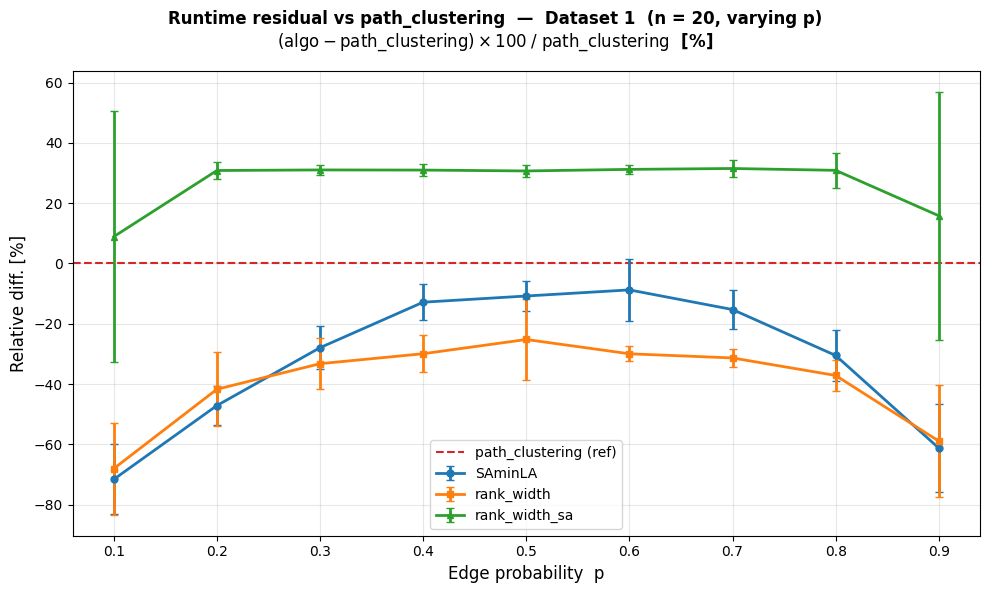

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/runtime_residual_vs_path_clustering_ds1.pdf


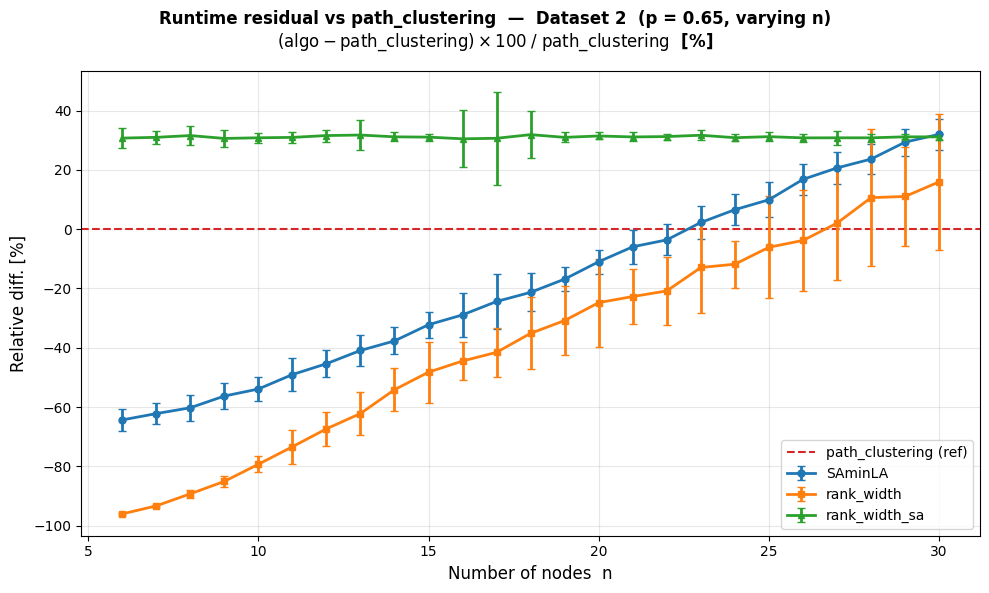

Saved → /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/step2_results_small/runtime_residual_vs_path_clustering_ds2.pdf


In [ ]:
# ── Residual runtime vs path_clustering: (algo - path_clustering)*100 / path_clustering ──
#
# R = (a - b) * 100 / b,  where a = algo time_mean, b = path_clustering time_mean
#
# Full first-order error propagation (a and b are independent):
#   σ_R = (100/b) * sqrt(σ_a² + (a/b)² * σ_b²)

def _extract_runtime(res_dict, keys):
    """Return (means, stds) of time_mean/time_std for an ordered list of keys."""
    means = [res_dict[k]["time_mean"] if k in res_dict else float("nan") for k in keys]
    stds  = [res_dict[k]["time_std"]  if k in res_dict else float("nan") for k in keys]
    return np.array(means), np.array(stds)

runtime_residual_algos = [
    ("SAminLA",       "tab:blue",   "o-",
     runtime_ds1_saminla,    runtime_ds2_saminla),
    ("rank_width",    "tab:orange", "s-",
     runtime_ds1_rw_refined, runtime_ds2_rw_refined),
    ("rank_width_sa", "tab:green",  "^-",
     runtime_ds1_rw_sa,      runtime_ds2_rw_sa),
]

for ds_idx, (ds_label, x_vals, x_lbl, keys, ref_rt, log_y) in enumerate([
    (f"Dataset 1  (n = {N_FIXED}, varying p)",
     probs_ds1, "Edge probability  p", keys_ds1,
     runtime_ds1_path_clustering, False),
    (f"Dataset 2  (p = {P_FIXED}, varying n)",
     nodes_ds2, "Number of nodes  n", keys_ds2,
     runtime_ds2_path_clustering, False),
], start=1):

    ref_m, ref_s = _extract_runtime(ref_rt, keys)

    log_suffix = "  [log y]" if log_y else ""
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(
        f"Runtime residual vs path_clustering  —  {ds_label}{log_suffix}\n"
        r"$({\rm algo} - {\rm path\_clustering})\times 100\;/\;{\rm path\_clustering}$  [%]",
        fontsize=12, fontweight="bold"
    )

    ax.axhline(0, color="tab:red", lw=1.5, ls="--", label="path_clustering (ref)")

    for alabel, acolor, amarker, ds1_rt, ds2_rt in runtime_residual_algos:
        rt = ds1_rt if ds_idx == 1 else ds2_rt
        algo_m, algo_s = _extract_runtime(rt, keys)

        residual_m = (algo_m - ref_m) * 100.0 / ref_m
        residual_s = (100.0 / ref_m) * np.sqrt(
            algo_s**2 + (algo_m / ref_m)**2 * ref_s**2
        )

        ax.errorbar(x_vals, residual_m, yerr=residual_s,
                    fmt=amarker, color=acolor,
                    capsize=3, lw=2, ms=5, label=alabel)

    ax.set_xlabel(x_lbl, fontsize=12)
    ax.set_ylabel("Relative diff. [%]", fontsize=12)
    if log_y:
        ax.set_yscale("symlog", linthresh=1)
        ax.grid(True, alpha=0.3, which="both")
    else:
        ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="best")

    plt.tight_layout()
    log_tag = "_logy" if log_y else ""
    fname = f"runtime_residual_vs_path_clustering_ds{ds_idx}{log_tag}.pdf"
    fpath = os.path.join(RESULTS_DIR, fname)
    plt.savefig(fpath, dpi=150)
    plt.show()
    print(f"Saved → {fpath}")
